# Notebook 2 — ME/CFS Metabolite Interpretation / Downstream Analysis

Cleaned version. This notebook **does not fit or export new coefficients for the locked 10-metabolite panel**. Any 10-metabolite coefficients/intercept should come only from Notebook 1.

Notebook 2 is for interpretation/downstream work: loading the locked panel, loading Notebook 1 scores/artifacts, plotting score distributions, checking metadata relationships, multi-omics exploratory comparisons, robustness checks, and final exports.

In [1]:
# =========================
# 0. Imports + paths
# =========================

import os
import re
import itertools
import warnings
from pathlib import Path
from collections import Counter

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from scipy.special import expit

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split
)

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

BASE = "../.."

META_PATH = f"{BASE}/data/metadata/Metadata_061523.csv"
METAB_PATH = f"{BASE}/data/metabolomics/Metabolomics_maaslined_norun.csv"

QUEST_PATH = f"{BASE}/data/quest_lab/Quest_lab_maaslined.csv"

IMMUNE_PCT_PATH = f"{BASE}/data/immuno/Immune_percentage.csv"
IMMUNE_RES_PATH = f"{BASE}/data/immuno/Immune_residue.csv"

KEGG_PATH = f"{BASE}/data/metagenomics/KEGG_maaslined.csv"
SPECIES_PATH = f"{BASE}/data/metagenomics/Specie_abundance_maaslined.csv"

OUT_DIR = Path(f"{BASE}/output/locked_panel_biology")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FINAL_DIR = Path(f"{BASE}/output/FINAL_MECFS_SIGNATURE_EXPORT")
FINAL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("Current folder:", Path.cwd())
print("Metadata exists:", Path(META_PATH).exists())
print("Metabolomics exists:", Path(METAB_PATH).exists())

Current folder: c:\Users\rohan\OneDrive\Desktop\ME-CFS\src\main
Metadata exists: True
Metabolomics exists: True


In [2]:
# =========================
# 1. Locked 10-metabolite panel from Notebook 1
# =========================
# Important: do NOT compute the 10-panel coefficients in this notebook.
# The panel itself is okay to define here, but coefficients/intercept must come from Notebook 1.

LOCKED_PANEL = [
    "1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)",
    "N-acetylglutamate",
    "N4-acetylcytidine",
    "sphingomyelin (d18:1/24:1, d18:2/24:0)*",
    "1-methylurate",
    "N-palmitoyl-sphingosine (d18:1/16:0)",
    "3-(4-hydroxyphenyl)lactate",
    "N-acetylglucosamine/N-acetylgalactosamine",
    "vanillylmandelate (VMA)",
    "4-vinylguaiacol sulfate"
]

len(LOCKED_PANEL)


10

In [3]:
# =========================
# 2. Load baseline tp1 metabolomics + labels
# =========================

meta_raw = pd.read_csv(META_PATH)
metab_raw = pd.read_csv(METAB_PATH)

metab = (
    metab_raw
    .set_index("Unnamed: 0")
    .T
    .reset_index()
    .rename(columns={"index": "sample_id"})
)

metab["participant_id"] = (
    metab["sample_id"]
    .str.replace(r"_tp\d+$", "", regex=True)
)

metab["timepoint"] = (
    metab["sample_id"]
    .str.extract(r"_tp(\d+)")
)

tp1 = metab[metab["timepoint"] == "1"].copy()

meta_raw["participant_id"] = meta_raw["samples_id"].astype(str)
meta_tp1 = meta_raw[meta_raw["timepoints"] == "tp1"].copy()

df = tp1.merge(
    meta_tp1,
    on="participant_id",
    how="inner"
)

y = (
    df["study_ptorhc"]
    .map({"MECFS": 1, "Control": 0})
    .astype(int)
)

X_panel = df[LOCKED_PANEL].apply(
    pd.to_numeric,
    errors="coerce"
)

print("Panel data:", X_panel.shape)
print("Class counts:", y.value_counts().to_dict())
print("Missing:", X_panel.isna().sum().sum())

Panel data: (214, 10)
Class counts: {1: 135, 0: 79}
Missing: 0


In [4]:
# =========================
# 3. Load Notebook 1 score file
# =========================
# This keeps Notebook 2 from refitting the 10-metabolite model.
# Update this path to wherever Notebook 1 exported the subject-level scores.

NB1_SCORE_CANDIDATES = [
    Path(f"{BASE}/output/mecfs_metabolite_scores.csv"),
    Path(f"{BASE}/output/locked_panel_biology/mecfs_metabolite_scores.csv"),
    Path(f"{BASE}/output/FINAL_MECFS_SIGNATURE_EXPORT/03_subject_scores_10metab_15multiomics.csv"),
    Path(f"{BASE}/output/FINAL_MECFS_SIGNATURE_EXPORT/03_subject_scores.csv"),
]

score_path = f"{BASE}/src/MECFS_FINAL_SIGNATURES/NB2_MULTIOMICS_INTERPRETATION/04_subject_scores.csv"

if score_path is None:
    raise FileNotFoundError(
        "Could not find Notebook 1 score file. Export subject-level 10-metabolite scores from Notebook 1 first. "
        "Do not refit the 10-metabolite coefficient model in Notebook 2."
    )

score_df = pd.read_csv(score_path)

# Normalize expected column names if needed.
if "score" in score_df.columns and "mecfs_score" not in score_df.columns:
    score_df = score_df.rename(columns={"score": "mecfs_score"})

required_score_cols = {"participant_id", "mecfs_score"}
missing = required_score_cols - set(score_df.columns)
if missing:
    raise ValueError(f"Score file is missing required columns: {missing}")

if "label" not in score_df.columns:
    score_df = score_df.merge(
        df[["participant_id"]].assign(label=y.values),
        on="participant_id",
        how="left"
    )

print("Loaded scores from:", score_path)
print(score_df.shape)
display(score_df.head())


Loaded scores from: ../../src/MECFS_FINAL_SIGNATURES/NB2_MULTIOMICS_INTERPRETATION/04_subject_scores.csv
(249, 5)


,participant_id,label,mecfs_score,multiomics_score,delta
0,SAM000269,1.0,0.636568,0.736132,0.099564
1,SAM000268,1.0,0.740155,0.427131,-0.313025
2,SAM000266,1.0,0.516147,0.303384,-0.212762
3,SAM000257,0.0,0.100672,0.036903,-0.063769
4,SAM000260,1.0,0.868054,0.837209,-0.030846


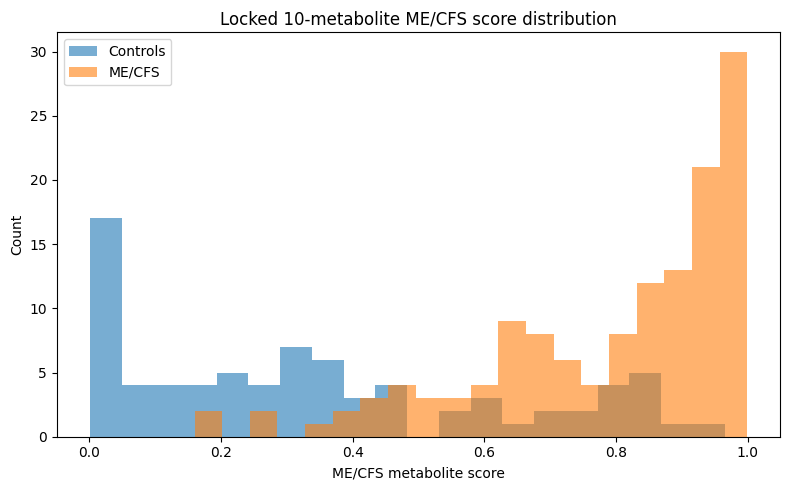

In [5]:
# =========================
# 4. Score distribution plot
# =========================

plt.figure(figsize=(8, 5))

plt.hist(
    score_df.loc[score_df["label"] == 0, "mecfs_score"],
    bins=20,
    alpha=0.6,
    label="Controls"
)

plt.hist(
    score_df.loc[score_df["label"] == 1, "mecfs_score"],
    bins=20,
    alpha=0.6,
    label="ME/CFS"
)

plt.xlabel("ME/CFS metabolite score")
plt.ylabel("Count")
plt.title("Locked 10-metabolite ME/CFS score distribution")
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "mecfs_score_distribution.png", dpi=300)
plt.show()


In [6]:
# =========================
# 5. Merge score with metadata
# =========================

score_meta = score_df.merge(
    meta_raw,
    left_on="participant_id",
    right_on="samples_id",
    how="left"
)

print(score_meta.shape)
display(score_meta.head())


(249, 28)


,participant_id_x,label,mecfs_score,multiomics_score,delta,Unnamed: 0,sample_id_tp1,samples_id,timepoints,study_ptorhc,...,diet_sugar,diet_veg,diet_grains,diet_fruit,antifungals,antibiotics,probiotics,antivirals,IBS,participant_id_y
0,SAM000269,1.0,0.636568,0.736132,0.099564,SAM000269_tp1,SAM000269,SAM000269,tp1,MECFS,...,4.0,2.0,4.0,3.0,No,No,No,No,2.0,SAM000269
1,SAM000268,1.0,0.740155,0.427131,-0.313025,SAM000268_tp1,SAM000268,SAM000268,tp1,MECFS,...,2.0,3.0,4.0,4.0,No,No,No,No,1.0,SAM000268
2,SAM000266,1.0,0.516147,0.303384,-0.212762,SAM000266_tp1,SAM000266,SAM000266,tp1,MECFS,...,4.0,2.0,1.0,2.0,No,No,No,No,3.0,SAM000266
3,SAM000257,0.0,0.100672,0.036903,-0.063769,SAM000257_tp1,SAM000257,SAM000257,tp1,Control,...,4.0,3.0,2.0,4.0,No,No,No,No,NaN,SAM000257
4,SAM000260,1.0,0.868054,0.837209,-0.030846,SAM000260_tp1,SAM000260,SAM000260,tp1,MECFS,...,3.0,4.0,1.0,3.0,No,No,No,No,3.0,SAM000260


In [7]:
# =========================
# 6. Correlate numeric metadata with Notebook 1 metabolite score
# =========================

numeric_cols = score_meta.select_dtypes(include="number").columns.tolist()
rows = []

for c in numeric_cols:
    if c in ["label", "mecfs_score"]:
        continue

    temp = score_meta[["mecfs_score", c]].dropna()

    if len(temp) > 20:
        rows.append({
            "variable": c,
            "spearman_corr_with_score": temp["mecfs_score"].corr(temp[c], method="spearman"),
            "n": len(temp)
        })

corr_df = (
    pd.DataFrame(rows)
    .sort_values("spearman_corr_with_score", key=abs, ascending=False)
)

display(corr_df.head(30))


,variable,spearman_corr_with_score,n
0,multiomics_score,0.842943,214
2,age,0.142699,214
3,bmi,0.111726,177
7,diet_grains,-0.107235,211
1,delta,0.101070,214
9,IBS,0.089789,134
6,diet_veg,-0.089506,211
8,diet_fruit,0.078242,211
4,diet_meat,0.026525,211
5,diet_sugar,0.001617,211


In [8]:
# =========================
# 9. Helper functions for multi-omics loading
# =========================

def strip_tp(x):
    return re.sub(r"_tp\d+$", "", str(x))

def get_tp(x):
    m = re.search(r"_tp(\d+)$", str(x))
    return m.group(1) if m else np.nan

def load_transposed_omics(path, prefix, min_complete=0.80):
    raw = pd.read_csv(path)
    feature_col = raw.columns[0]

    mat = (
        raw
        .set_index(feature_col)
        .T
        .reset_index()
        .rename(columns={"index": "sample_id"})
    )

    mat["participant_id"] = mat["sample_id"].apply(strip_tp)
    mat["tp"] = mat["sample_id"].apply(get_tp)

    if mat["tp"].notna().any():
        mat = mat[mat["tp"] == "1"].copy()

    mat = mat.drop(columns=["sample_id", "tp"], errors="ignore")
    mat = mat.set_index("participant_id")
    mat = mat.apply(pd.to_numeric, errors="coerce")
    mat = mat.loc[:, mat.notna().mean() > min_complete]
    mat.columns = [f"{prefix}__{c}" for c in mat.columns]

    return mat


In [9]:
# =========================
# 10. Build multi-omics modalities
# =========================

label_df = meta_tp1[["participant_id", "study_ptorhc"]].drop_duplicates()
label_df["y"] = label_df["study_ptorhc"].map({"MECFS": 1, "Control": 0})
label_df = label_df.dropna(subset=["y"]).copy()
label_df["y"] = label_df["y"].astype(int)
label_df = label_df.set_index("participant_id")

modalities = {}

# Locked metabolite panel only. The features are used as predictors, but the 10-panel coefficients still come from Notebook 1.
metab_all = load_transposed_omics(METAB_PATH, "metab")
modalities["metabaolites"] = metab_all.copy()

# Metadata covariates
meta_cov = meta_tp1.set_index("participant_id")[["age", "bmi", "gender"]].copy()
meta_cov = pd.get_dummies(meta_cov, columns=["gender"], drop_first=True)
modalities["metadata"] = meta_cov.apply(pd.to_numeric, errors="coerce")

# QUEST
if Path(QUEST_PATH).exists():
    modalities["quest"] = load_transposed_omics(QUEST_PATH, "quest")

# Immune
if Path(IMMUNE_PCT_PATH).exists():
    modalities["immune_percentage"] = load_transposed_omics(IMMUNE_PCT_PATH, "immune_pct")

if Path(IMMUNE_RES_PATH).exists():
    modalities["immune_residue"] = load_transposed_omics(IMMUNE_RES_PATH, "immune_res")

# Microbiome / metagenomics
if Path(KEGG_PATH).exists():
    modalities["kegg"] = load_transposed_omics(KEGG_PATH, "kegg")

if Path(SPECIES_PATH).exists():
    modalities["species"] = load_transposed_omics(SPECIES_PATH, "species")

print("Loaded modalities:")
for name, Xmod in modalities.items():
    print(name, Xmod.shape)


Loaded modalities:
metabaolites (215, 876)
metadata (249, 3)
quest (242, 37)
immune_percentage (239, 311)
immune_residue (239, 311)
kegg (238, 4429)
species (238, 118)


In [10]:
# =========================
# 12. Build one multi-omics matrix
# =========================
# Adjust this list if you decide to exclude a modality.

all_modalities = pd.concat([
    modalities[name]
    for name in [
        "metabaolites",
        "quest",
        "immune_residue",
        "species",
        "metadata",
        "kegg"
    ]
    if name in modalities
], axis=1)

multi_df = all_modalities.join(label_df["y"], how="inner")

X_multi = multi_df.drop(columns=["y"])
y_multi = multi_df["y"].astype(int)

print("X_multi:", X_multi.shape)
print("y_multi:", y_multi.value_counts().to_dict())
X_multi.head()


X_multi: (249, 5774)
y_multi: {1: 153, 0: 96}


,metab__S-1-pyrroline-5-carboxylate,metab__1-methylnicotinamide,metab__alpha-ketoglutarate,metab__3-hydroxyisobutyrate,metab__3-hydroxy-3-methylglutarate,metab__cholate,metab__4-hydroxyphenylacetate,"metab__5,6-dihydrothymine","metab__9,10-DiHOME",metab__linoleate (18:2n6),...,kegg__K23508,kegg__K23509,kegg__K23518,kegg__K23535,kegg__K23536,kegg__K23537,kegg__K23541,kegg__K23546,kegg__K23547,kegg__K23573
participant_id,,,,,,,,,,,,,,,,,,,,,
SAM000269,1.476325,0.387559,0.342713,0.488864,0.907234,0.341328,0.139780,0.805863,0.129607,0.918709,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SAM000268,1.411830,1.383625,0.350704,0.187794,1.005262,0.830513,0.945841,1.184571,0.122377,0.685851,...,87.290443,1.983874,504.895857,2.975811,0.000000,126.967917,3.967747,0.000000,0.000000,6.943558
SAM000266,0.566404,0.840769,0.464346,1.405387,1.436603,1.130044,1.838309,1.333872,0.592418,1.293946,...,176.380662,94.489640,404.415660,0.000000,0.000000,56.693784,5.039447,2.519724,0.000000,7.559171
SAM000257,1.481165,0.846519,0.483156,0.437858,1.052833,0.362826,0.139780,1.732946,0.493230,0.463149,...,36.898544,0.000000,427.408129,6.149757,6.149757,49.198058,6.149757,0.000000,0.000000,12.299515
SAM000260,0.496603,0.478453,0.431380,1.225215,0.852716,0.378776,0.545194,1.669577,0.573258,1.210857,...,114.487336,14.310917,479.415720,1.192576,1.192576,32.199563,3.577729,8.348035,1.192576,1.192576


In [11]:
# =========================
# 13. Multi-omics stability selection with LASSO
# =========================

C_GRID = [0.01, 0.03, 0.06, 0.1, 0.3]
N_REPEATS = 20

selection_counts = Counter()


def clean_feature_name(feature):
    # Preserve modality prefix for multi-omics features.
    return feature

X_train, X_test, y_train, y_test = train_test_split(
            X_multi,
            y_multi,
            test_size=0.20,
            stratify=y_multi,
            random_state=42
    )

for repeat in range(N_REPEATS):
    repeated_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE + repeat)
    
    

    for train_idx, _ in repeated_cv.split(X_train, y_train):
        X_fold = X_train.iloc[train_idx]
        y_fold = y_train.iloc[train_idx]

        for C in C_GRID:
            model = Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("lasso", LogisticRegression(
                    penalty="l1",
                    solver="liblinear",
                    C=C,
                    max_iter=5000,
                    random_state=RANDOM_STATE
                ))
            ])

            model.fit(X_fold, y_fold)
            coef = model.named_steps["lasso"].coef_[0]
            selected = X_multi.columns[coef != 0]
            selection_counts.update(selected)

multi_stability = pd.DataFrame({
    "feature": selection_counts.keys(),
    "count": selection_counts.values()
})

multi_stability["frequency"] = multi_stability["count"] / (N_REPEATS * 5 * len(C_GRID))
multi_stability = multi_stability.sort_values("frequency", ascending=False)

display(multi_stability.head(50))
multi_stability.to_csv(OUT_DIR / "multiomics_stability_selection.csv", index=False)


,feature,count,frequency
25,quest__Vitamin B12,297,0.594
8,kegg__K02121,285,0.570
15,metab__3-(4-hydroxyphenyl)lactate,239,0.478
5,metab__1-stearoyl-2-docosahexaenoyl-GPC (18:0/...,235,0.470
17,metab__N4-acetylcytidine,232,0.464
7,species__GGB1266_SGB1699,219,0.438
0,metab__N-palmitoyl-sphingosine (d18:1/16:0),218,0.436
1,metab__N-acetylglutamate,211,0.422
2,metab__1-methylurate,186,0.372
18,metab__N-acetylglucosamine/N-acetylgalactosamine,169,0.338


In [12]:
# =========================
# 14. Evaluate multi-omics panel sizes
# =========================

panel_sizes = [5, 10, 15, 20, 30]
rows = []

for k in panel_sizes:
    panel = multi_stability.head(k)["feature"].tolist()

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    aucs = cross_val_score(
        model,
        X_train[panel],
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        scoring="roc_auc"
    )

    rows.append({
        "panel_size": k,
        "mean_auc": aucs.mean(),
        "std_auc": aucs.std(),
        "features": panel
    })

panel_results_df = pd.DataFrame(rows)
display(panel_results_df)
panel_results_df.to_csv(OUT_DIR / "multiomics_panel_size_cv.csv", index=False)


,panel_size,mean_auc,std_auc,features
0,5,0.856794,0.066405,"[quest__Vitamin B12, kegg__K02121, metab__3-(4..."
1,10,0.906244,0.040949,"[quest__Vitamin B12, kegg__K02121, metab__3-(4..."
2,15,0.929323,0.048157,"[quest__Vitamin B12, kegg__K02121, metab__3-(4..."
3,20,0.921135,0.039880,"[quest__Vitamin B12, kegg__K02121, metab__3-(4..."
4,30,0.947823,0.021890,"[quest__Vitamin B12, kegg__K02121, metab__3-(4..."


In [13]:
# =========================
# 15. Lock final multi-omics panel
# =========================
# Edit this number if the panel-size analysis suggests a different cutoff.

MULTIOMICS_PANEL_SIZE = 15
MULTIOMICS_PANEL = multi_stability.head(MULTIOMICS_PANEL_SIZE)["feature"].tolist()

print("Locked multi-omics panel size:", len(MULTIOMICS_PANEL))
for f in MULTIOMICS_PANEL:
    print("-", f)


Locked multi-omics panel size: 15
- quest__Vitamin B12
- kegg__K02121
- metab__3-(4-hydroxyphenyl)lactate
- metab__1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)
- metab__N4-acetylcytidine
- species__GGB1266_SGB1699
- metab__N-palmitoyl-sphingosine (d18:1/16:0)
- metab__N-acetylglutamate
- metab__1-methylurate
- metab__N-acetylglucosamine/N-acetylgalactosamine
- immune_res__% CD8+ M CCR6+ CXCR3- d0
- metab__1-stearoyl-2-oleoyl-GPC (18:0/18:1)
- metab__sphingomyelin (d18:1/24:1, d18:2/24:0)*
- metab__vanillylmandelate (VMA)
- species__Dysosmobacter_welbionis


In [14]:
# =========================
# 16. Final multi-omics score model + coefficients
# =========================
# These coefficients are for the multi-omics model only.
# Do not treat these as the locked 10-metabolite coefficients.

final_multi_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

final_multi_model.fit(X_train[MULTIOMICS_PANEL], y_train)

test_probs = final_multi_model.predict_proba(X_test[MULTIOMICS_PANEL])[:, 1]

test_score_df = pd.DataFrame({
    "participant_id": X_test.index,
    "label": y_test.values,
    "multiomics_score": test_probs
})

test_coef = pd.Series(
    final_multi_model.named_steps["logreg"].coef_[0],
    index=MULTIOMICS_PANEL,
    name="coefficient"
).sort_values(key=abs, ascending=False)

print("test multi-omics AUC:", roc_auc_score(y_test, test_probs))
display(test_score_df.head())
display(test_coef.reset_index().rename(columns={"index": "feature"}))


# -------------------------------
multi_probs = final_multi_model.predict_proba(X_multi[MULTIOMICS_PANEL])[:, 1]

multi_score_df = pd.DataFrame({
    "participant_id": X_multi.index,
    "label": y_multi.values,
    "multiomics_score": multi_probs
})

multi_coef = pd.Series(
    final_multi_model.named_steps["logreg"].coef_[0],
    index=MULTIOMICS_PANEL,
    name="coefficient"
).sort_values(key=abs, ascending=False)

print("full multi-omics AUC:", roc_auc_score(y_multi, multi_probs))
display(multi_score_df.head())
display(multi_coef.reset_index().rename(columns={"index": "feature"}))


test multi-omics AUC: 0.8200339558573854


,participant_id,label,multiomics_score
0,SAM000490,0,0.298505
1,SAM000279,1,0.960135
2,SAM000326,0,0.911182
3,SAM000276,1,0.290944
4,SAM000467,0,0.003273


,feature,coefficient
0,metab__N-acetylglutamate,1.040520
1,metab__vanillylmandelate (VMA),-0.999361
2,kegg__K02121,0.983886
3,metab__N4-acetylcytidine,0.960111
4,quest__Vitamin B12,0.865884
5,metab__3-(4-hydroxyphenyl)lactate,-0.680154
6,metab__1-methylurate,-0.635737
7,immune_res__% CD8+ M CCR6+ CXCR3- d0,0.614209
8,species__GGB1266_SGB1699,-0.614199
9,metab__N-palmitoyl-sphingosine (d18:1/16:0),0.572794


full multi-omics AUC: 0.9254493464052287


,participant_id,label,multiomics_score
0,SAM000269,1,0.530959
1,SAM000268,1,0.566659
2,SAM000266,1,0.208924
3,SAM000257,0,0.020655
4,SAM000260,1,0.761518


,feature,coefficient
0,metab__N-acetylglutamate,1.040520
1,metab__vanillylmandelate (VMA),-0.999361
2,kegg__K02121,0.983886
3,metab__N4-acetylcytidine,0.960111
4,quest__Vitamin B12,0.865884
5,metab__3-(4-hydroxyphenyl)lactate,-0.680154
6,metab__1-methylurate,-0.635737
7,immune_res__% CD8+ M CCR6+ CXCR3- d0,0.614209
8,species__GGB1266_SGB1699,-0.614199
9,metab__N-palmitoyl-sphingosine (d18:1/16:0),0.572794


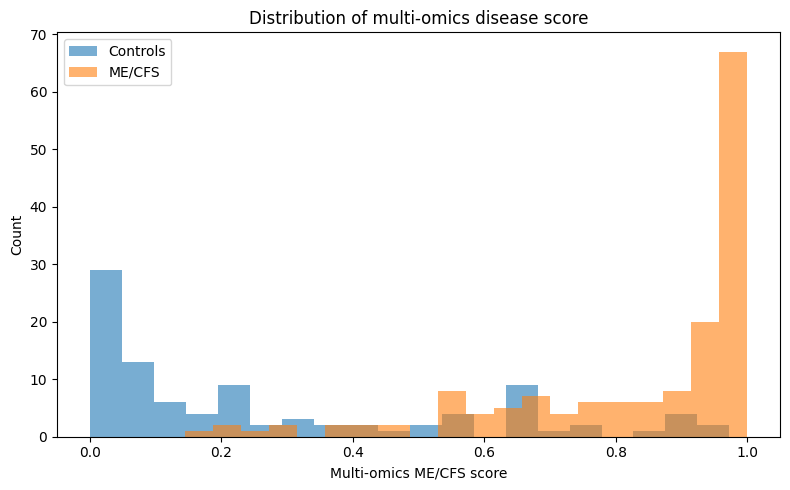

Mann-Whitney p = 1.3616659030115037e-29


In [15]:
# =========================
# 17. Multi-omics score distribution
# =========================

plt.figure(figsize=(8, 5))

plt.hist(
    multi_score_df.loc[multi_score_df["label"] == 0, "multiomics_score"],
    bins=20,
    alpha=0.6,
    label="Controls"
)

plt.hist(
    multi_score_df.loc[multi_score_df["label"] == 1, "multiomics_score"],
    bins=20,
    alpha=0.6,
    label="ME/CFS"
)

plt.xlabel("Multi-omics ME/CFS score")
plt.ylabel("Count")
plt.title("Distribution of multi-omics disease score")
plt.legend()
plt.tight_layout()
plt.show()

u, p = mannwhitneyu(
    multi_score_df.loc[multi_score_df["label"] == 0, "multiomics_score"],
    multi_score_df.loc[multi_score_df["label"] == 1, "multiomics_score"]
)
print("Mann-Whitney p =", p)


In [16]:
print(multi_score_df.loc[multi_score_df["label"] == 1, "multiomics_score"].describe())
print(multi_score_df.loc[multi_score_df["label"] == 0, "multiomics_score"].describe())

# FUTURE ROHAN - WE NEED TO TIGHTEN THE RANGES EFFECTIVELY (drop the SD to make these probabilities better)

count    153.000000
mean       0.836850
std        0.205752
min        0.144674
25%        0.730117
50%        0.933650
75%        0.990407
max        0.999986
Name: multiomics_score, dtype: float64
count    96.000000
mean      0.269443
std       0.291698
min       0.000006
25%       0.025553
50%       0.137596
75%       0.504727
max       0.973081
Name: multiomics_score, dtype: float64


In [17]:
# =========================
# 18. Compare Notebook 1 metabolite score vs multi-omics score
# =========================

combined_scores = (
    score_df[["participant_id", "label", "mecfs_score"]]
    .merge(
        multi_score_df[["participant_id", "multiomics_score"]],
        on="participant_id",
        how="outer"
    )
)

combined_scores["delta"] = combined_scores["multiomics_score"] - combined_scores["mecfs_score"]

score_corr = combined_scores["mecfs_score"].corr(combined_scores["multiomics_score"])
print("Score correlation:", score_corr)

display(combined_scores.head())


Score correlation: 0.833783781326624


,participant_id,label,mecfs_score,multiomics_score,delta
0,SAM000269,1.0,0.636568,0.530959,-0.105609
1,SAM000268,1.0,0.740155,0.566659,-0.173496
2,SAM000266,1.0,0.516147,0.208924,-0.307223
3,SAM000257,0.0,0.100672,0.020655,-0.080017
4,SAM000260,1.0,0.868054,0.761518,-0.106536


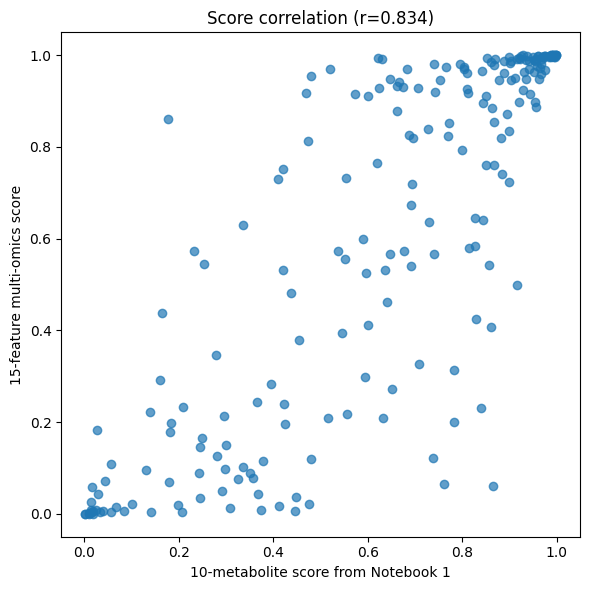

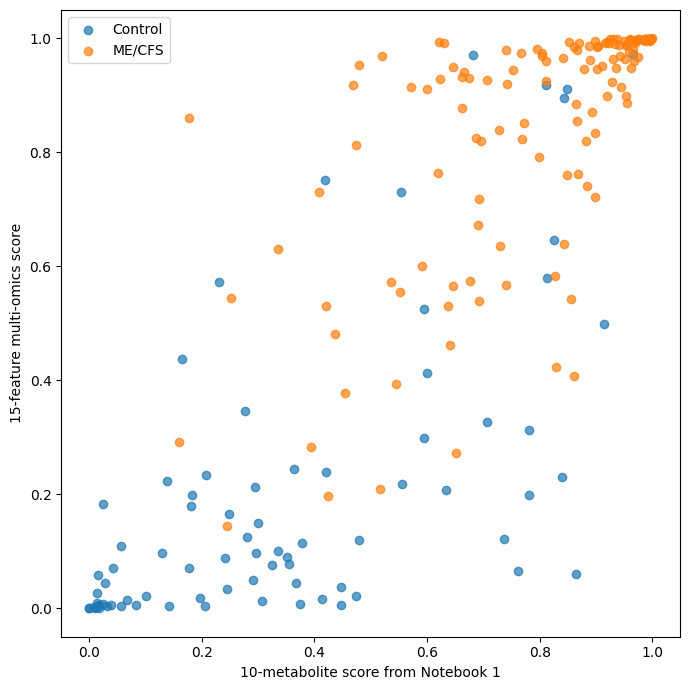

In [18]:
# =========================
# 19. Score correlation plots
# =========================

plt.figure(figsize=(6, 6))
plt.scatter(combined_scores["mecfs_score"], combined_scores["multiomics_score"], alpha=0.7)
plt.xlabel("10-metabolite score from Notebook 1")
plt.ylabel("15-feature multi-omics score")
plt.title(f"Score correlation (r={score_corr:.3f})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 7))
for label, name in [(0, "Control"), (1, "ME/CFS")]:
    tmp = combined_scores[combined_scores["label"] == label]
    plt.scatter(tmp["mecfs_score"], tmp["multiomics_score"], alpha=0.7, label=name)

plt.xlabel("10-metabolite score from Notebook 1")
plt.ylabel("15-feature multi-omics score")
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
# =========================
# 20. Repeated train/test robustness checks
# =========================

N_SPLITS = 500
results = []

for model_name, X_data, y_data, panel in [
    ("10_metabolite_predictors_only", X_panel, y, LOCKED_PANEL),
    ("15_multiomics", X_multi, y_multi, MULTIOMICS_PANEL)
]:
    aucs = []

    for seed in range(N_SPLITS):
        X_train, X_test, y_train, y_test = train_test_split(
            X_data[panel],
            y_data,
            test_size=0.20,
            stratify=y_data,
            random_state=seed
        )

        pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("logreg", LogisticRegression(
                penalty="l2",
                solver="liblinear",
                max_iter=5000,
                random_state=seed
            ))
        ])

        pipe.fit(X_train, y_train)
        probs = pipe.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, probs))

    aucs = np.array(aucs)

    results.append({
        "model": model_name,
        "mean_auc": aucs.mean(),
        "median_auc": np.median(aucs),
        "std_auc": aucs.std(),
        "min_auc": aucs.min(),
        "max_auc": aucs.max(),
        "q05": np.quantile(aucs, 0.05),
        "q25": np.quantile(aucs, 0.25),
        "q75": np.quantile(aucs, 0.75),
        "q95": np.quantile(aucs, 0.95)
    })

    print(f"\n===== {model_name} =====")
    print(f"Mean AUC   : {aucs.mean():.3f}")
    print(f"Median AUC : {np.median(aucs):.3f}")
    print(f"Std AUC    : {aucs.std():.3f}")
    print(f"5th pct    : {np.quantile(aucs, 0.05):.3f}")
    print(f"95th pct   : {np.quantile(aucs, 0.95):.3f}")

robustness_summary = pd.DataFrame(results)
display(robustness_summary)



===== 10_metabolite_predictors_only =====
Mean AUC   : 0.859
Median AUC : 0.861
Std AUC    : 0.056
5th pct    : 0.757
95th pct   : 0.942

===== 15_multiomics =====
Mean AUC   : 0.909
Median AUC : 0.910
Std AUC    : 0.037
5th pct    : 0.844
95th pct   : 0.966


,model,mean_auc,median_auc,std_auc,min_auc,max_auc,q05,q25,q75,q95
0,10_metabolite_predictors_only,0.859014,0.861111,0.055981,0.666667,0.981481,0.756944,0.823495,0.900463,0.942130
1,15_multiomics,0.908947,0.910441,0.037317,0.792869,0.988115,0.843676,0.886036,0.937182,0.966044


Real AUC: 0.82
Null mean AUC: 0.5034
Null std AUC: 0.1387
Permutation p-value: 0.003996003996003996


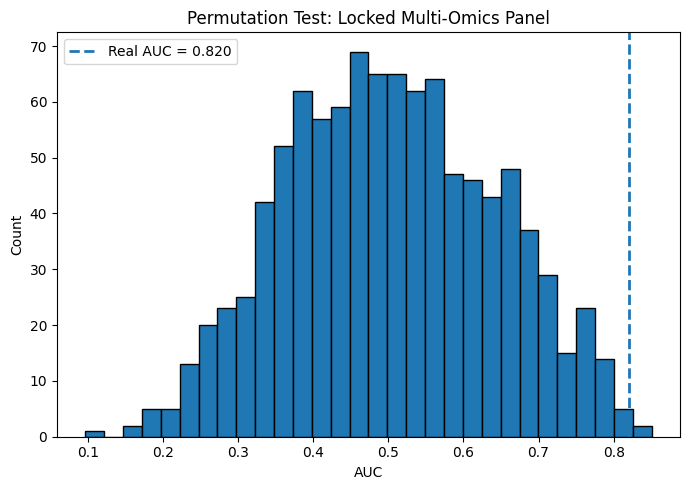

In [20]:
# =========================
# 21. Permutation test: locked multi-omics panel
# =========================

N_PERMUTATIONS = 1000

X_train, X_test, y_train, y_test = train_test_split(
    X_multi[MULTIOMICS_PANEL],
    y_multi,
    test_size=0.20,
    stratify=y_multi,
    random_state=RANDOM_STATE
)

real_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE
    ))
])

real_model.fit(X_train, y_train)
real_auc = roc_auc_score(y_test, real_model.predict_proba(X_test)[:, 1])

perm_aucs = []
rng = np.random.default_rng(RANDOM_STATE)

for i in range(N_PERMUTATIONS):
    y_perm = rng.permutation(y_train)

    perm_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000
        ))
    ])

    perm_model.fit(X_train, y_perm)
    perm_probs = perm_model.predict_proba(X_test)[:, 1]
    perm_aucs.append(roc_auc_score(y_test, perm_probs))

perm_aucs = np.array(perm_aucs)
p_value = (np.sum(perm_aucs >= real_auc) + 1) / (N_PERMUTATIONS + 1)

print("Real AUC:", round(real_auc, 4))
print("Null mean AUC:", round(perm_aucs.mean(), 4))
print("Null std AUC:", round(perm_aucs.std(), 4))
print("Permutation p-value:", p_value)

plt.figure(figsize=(7, 5))
plt.hist(perm_aucs, bins=30, edgecolor="black")
plt.axvline(real_auc, linestyle="--", linewidth=2, label=f"Real AUC = {real_auc:.3f}")
plt.xlabel("AUC")
plt.ylabel("Count")
plt.title("Permutation Test: Locked Multi-Omics Panel")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
# ==========================================
# NB2 FINAL EXPORT
# ==========================================

from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent / "MECFS_FINAL_SIGNATURES"
NB2_DIR = ROOT / "NB3_MULTIOMICS_INTERPRETATION"

NB2_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------
# Locked panel
# ------------------------------------------

pd.DataFrame({
    "feature": MULTIOMICS_PANEL
}).to_csv(
    NB2_DIR / "01_locked_15_multiomics_panel.csv",
    index=False
)

# ------------------------------------------
# Coefficients
# ------------------------------------------

multi_coef.rename("coefficient").reset_index().rename(
    columns={"index": "feature"}
).to_csv(
    NB2_DIR / "02_15_multiomics_coefficients.csv",
    index=False
)

# ------------------------------------------
# Intercept
# ------------------------------------------

pd.DataFrame({
    "intercept": [
        final_multi_model.named_steps["logreg"].intercept_[0]
    ]
}).to_csv(
    NB2_DIR / "03_15_multiomics_intercept.csv",
    index=False
)

# ------------------------------------------
# Subject scores
# ------------------------------------------

combined_scores.to_csv(
    NB2_DIR / "04_subject_scores.csv",
    index=False
)

# ------------------------------------------
# Feature stability
# ------------------------------------------

multi_stability.to_csv(
    NB2_DIR / "05_multiomics_feature_stability.csv",
    index=False
)

# ------------------------------------------
# Panel size optimization
# ------------------------------------------

panel_results_df.to_csv(
    NB2_DIR / "06_multiomics_panel_size_cv.csv",
    index=False
)

# ------------------------------------------
# Robustness
# ------------------------------------------

robustness_summary.to_csv(
    NB2_DIR / "07_multiomics_robustness.csv",
    index=False
)

# ------------------------------------------
# Permutation test
# ------------------------------------------

pd.DataFrame([{
    "real_auc": real_auc,
    "null_mean_auc": np.mean(perm_aucs),
    "null_std_auc": np.std(perm_aucs),
    "permutation_p": p_value
}]).to_csv(
    NB2_DIR / "08_multiomics_permutation_test.csv",
    index=False
)

# ------------------------------------------
# Score correlation
# ------------------------------------------

pd.DataFrame([{
    "score_correlation": score_corr
}]).to_csv(
    NB2_DIR / "09_score_correlation.csv",
    index=False
)

print("Saved:")
print(NB2_DIR)

Saved:
c:\Users\rohan\OneDrive\Desktop\ME-CFS\src\MECFS_FINAL_SIGNATURES\NB3_MULTIOMICS_INTERPRETATION


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

PANEL = MULTIOMICS_PANEL   # or LOCKED_PANEL for 10-metabolite

X_model = X_multi[PANEL]
y_model = y_multi

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    stratify=y_model,
    random_state=42
)

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

pipe.fit(X_train, y_train)

probs = pipe.predict_proba(X_test)[:, list(pipe.classes_).index(1)]

print("classes:", pipe.classes_)
print("test n:", len(y_test))
print("AUC:", roc_auc_score(y_test, probs))

classes: [0 1]
test n: 50
AUC: 0.8200339558573854


In [23]:
from sklearn.metrics import roc_auc_score
import numpy as np

def bootstrap_auc_ci(y_true, probs, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)

    y_true = np.array(y_true)
    probs = np.array(probs)

    aucs = []

    for _ in range(n_boot):
        idx = rng.choice(len(y_true), len(y_true), replace=True)

        if len(np.unique(y_true[idx])) < 2:
            continue

        aucs.append(
            roc_auc_score(y_true[idx], probs[idx])
        )

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return np.mean(aucs), lower, upper

auc_mean, auc_low, auc_high = bootstrap_auc_ci(y_test, probs)

print(f"AUC: {roc_auc_score(y_test, probs):.3f}")
print(f"Bootstrap mean: {auc_mean:.3f}")
print(f"95% CI: [{auc_low:.3f}, {auc_high:.3f}]")

AUC: 0.820
Bootstrap mean: 0.819
95% CI: [0.693, 0.920]


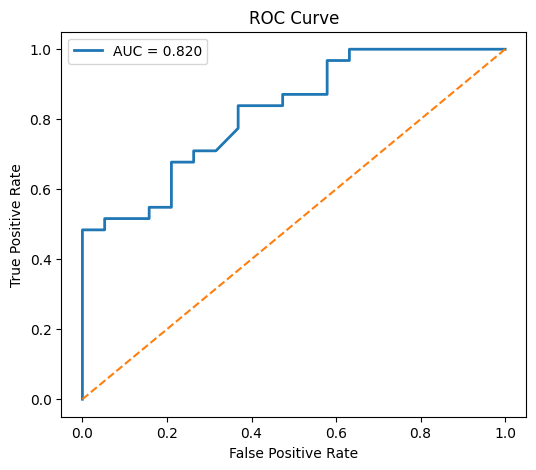

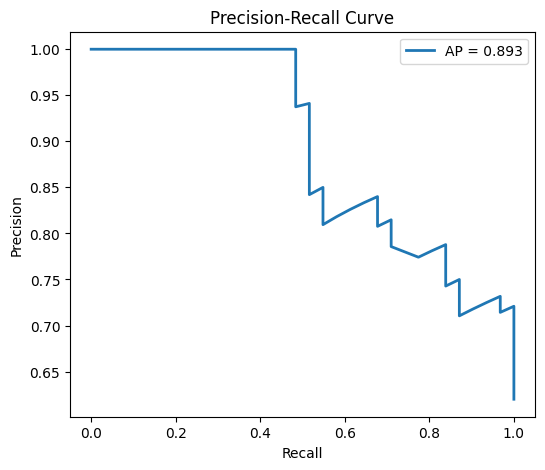

In [24]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ROC

fpr, tpr, roc_thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# PR

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    probs
)

ap = average_precision_score(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, lw=2,
         label=f"AP = {ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [25]:
from sklearn.metrics import confusion_matrix

# Youden's J

j_scores = tpr - fpr
best_idx = np.argmax(j_scores)

optimal_threshold = roc_thresholds[best_idx]

y_pred = (probs >= optimal_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

ppv = tp / (tp + fp)
npv = tn / (tn + fn)

accuracy = (tp + tn) / (tp + tn + fp + fn)

balanced_accuracy = (
    sensitivity + specificity
) / 2

print(f"Optimal threshold: {optimal_threshold:.3f}")
print()

print(f"Sensitivity: {sensitivity:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"PPV: {ppv:.3f}")
print(f"NPV: {npv:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"Balanced accuracy: {balanced_accuracy:.3f}")
print()

print("Confusion matrix:")
print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Optimal threshold: 0.933

Sensitivity: 0.484
Specificity: 1.000
PPV: 1.000
NPV: 0.543
Accuracy: 0.680
Balanced accuracy: 0.742

Confusion matrix:
TN=19, FP=0, FN=16, TP=15


In [26]:
import numpy as np
import pandas as pd

test_df = pd.DataFrame({
    "y_true": np.array(y_test),
    "prob_ME_CFS": np.array(probs)
})

print("Controls:")
print(test_df[test_df["y_true"] == 0]["prob_ME_CFS"].describe())

print("\nME/CFS:")
print(test_df[test_df["y_true"] == 1]["prob_ME_CFS"].describe())

print("\nHighest control probability:")
print(test_df[test_df["y_true"] == 0]["prob_ME_CFS"].max())

print("\nLowest ME/CFS probability:")
print(test_df[test_df["y_true"] == 1]["prob_ME_CFS"].min())

print("\nOptimal threshold used:")
print(optimal_threshold)

Controls:
count    19.000000
mean      0.434450
std       0.354865
min       0.003273
25%       0.079170
50%       0.524450
75%       0.741283
max       0.917803
Name: prob_ME_CFS, dtype: float64

ME/CFS:
count    31.000000
mean      0.794238
std       0.258208
min       0.144674
25%       0.658547
50%       0.915694
75%       0.994426
max       0.999986
Name: prob_ME_CFS, dtype: float64

Highest control probability:
0.9178026578098297

Lowest ME/CFS probability:
0.14467412423225656

Optimal threshold used:
0.9329674944507111


In [27]:
import numpy as np
import pandas as pd

score_df = pd.DataFrame({
    "y_true": np.array(y_test),
    "prob_ME_CFS": np.array(probs)
})

thresholds = np.arange(0.1, 1.0, 0.05)

rows = []

for low_cut in thresholds:
    for high_cut in thresholds:
        if low_cut >= high_cut:
            continue

        called_low = score_df["prob_ME_CFS"] < low_cut
        called_high = score_df["prob_ME_CFS"] > high_cut
        inconclusive = ~(called_low | called_high)

        low_group = score_df[called_low]
        high_group = score_df[called_high]

        low_correct = (low_group["y_true"] == 0).mean() if len(low_group) > 0 else np.nan
        high_correct = (high_group["y_true"] == 1).mean() if len(high_group) > 0 else np.nan

        rows.append({
            "low_cut": low_cut,
            "high_cut": high_cut,
            "n_low_called": len(low_group),
            "n_high_called": len(high_group),
            "n_inconclusive": inconclusive.sum(),
            "low_correct_rate": low_correct,
            "high_correct_rate": high_correct,
            "coverage": 1 - inconclusive.mean()
        })

range_df = pd.DataFrame(rows)

range_df.sort_values(
    ["high_correct_rate", "low_correct_rate", "coverage"],
    ascending=False
).head(20)

,low_cut,high_cut,n_low_called,n_high_called,n_inconclusive,low_correct_rate,high_correct_rate,coverage
16,0.10,0.95,7,14,29,1.000000,1.000000,0.42
32,0.15,0.95,8,14,28,0.875000,1.000000,0.44
47,0.20,0.95,8,14,28,0.875000,1.000000,0.44
61,0.25,0.95,8,14,28,0.875000,1.000000,0.44
74,0.30,0.95,13,14,23,0.692308,1.000000,0.54
86,0.35,0.95,13,14,23,0.692308,1.000000,0.54
97,0.40,0.95,13,14,23,0.692308,1.000000,0.54
107,0.45,0.95,13,14,23,0.692308,1.000000,0.54
116,0.50,0.95,13,14,23,0.692308,1.000000,0.54
124,0.55,0.95,15,14,21,0.666667,1.000000,0.58


In [28]:
# =========================
# All-feature multiomics vs locked 15-feature panel
# Held-out AUC + score correlation
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# -------------------------
# Helper function
# -------------------------

def fit_eval_and_oof_scores(X_data, y_data, model_name, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data,
        y_data,
        test_size=0.20,
        stratify=y_data,
        random_state=random_state
    )

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=random_state
        ))
    ])

    model.fit(X_train, y_train)

    test_probs = model.predict_proba(X_test)[:, list(model.classes_).index(1)]
    heldout_auc = roc_auc_score(y_test, test_probs)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    oof_probs = cross_val_predict(
        model,
        X_data,
        y_data,
        cv=cv,
        method="predict_proba"
    )[:, 1]

    score_df = pd.DataFrame({
        "participant_id": X_data.index.astype(str),
        "label": y_data.values,
        f"{model_name}_score": oof_probs
    })

    return heldout_auc, score_df


# -------------------------
# 1. All-feature multiomics
# -------------------------

X_all = X_multi.copy()
y_all = y_multi.copy()

auc_all, all_score_df = fit_eval_and_oof_scores(
    X_all,
    y_all,
    model_name="all_feature"
)

print("All-feature multiomics shape:", X_all.shape)
print("All-feature held-out AUC:", auc_all)


# -------------------------
# 2. Locked 15-feature multiomics panel
# -------------------------

X_15 = X_multi[MULTIOMICS_PANEL].copy()
y_15 = y_multi.copy()

auc_15, score15_df = fit_eval_and_oof_scores(
    X_15,
    y_15,
    model_name="panel15"
)

print("\n15-feature panel shape:", X_15.shape)
print("15-feature held-out AUC:", auc_15)


# -------------------------
# 3. Merge scores and correlate
# -------------------------

combined_scores = (
    score15_df
    .merge(
        all_score_df[["participant_id", "all_feature_score"]],
        on="participant_id",
        how="inner"
    )
)

score_corr = combined_scores["panel15_score"].corr(
    combined_scores["all_feature_score"]
)

print("\nMerged shape:", combined_scores.shape)
print("15-panel vs all-feature score correlation:", score_corr)

display(combined_scores.head())

All-feature multiomics shape: (249, 5774)
All-feature held-out AUC: 0.66723259762309

15-feature panel shape: (249, 15)
15-feature held-out AUC: 0.8200339558573854

Merged shape: (249, 4)
15-panel vs all-feature score correlation: 0.4757211206874544


,participant_id,label,panel15_score,all_feature_score
0,SAM000269,1,0.614891,0.036922
1,SAM000268,1,0.415562,1.000000
2,SAM000266,1,0.174845,0.000183
3,SAM000257,0,0.021727,0.000001
4,SAM000260,1,0.688006,0.160241


===== 500-split performance summary =====


,mean,median,std,q05,q95
auc,0.859014,0.861111,0.056037,0.756944,0.942130
brier,0.145466,0.145007,0.030408,0.099105,0.199360
accuracy,0.806419,0.813953,0.057528,0.720930,0.883721
balanced_accuracy,0.784231,0.788194,0.063995,0.677025,0.881944
sensitivity,0.870963,0.888889,0.067773,0.740741,0.962963
specificity,0.697500,0.687500,0.114856,0.500000,0.875000
PPV,0.832312,0.827586,0.054296,0.750000,0.923077
NPV,0.771066,0.769231,0.097727,0.624306,0.923352
FP,4.840000,5.000000,1.837704,2.000000,8.000000
FN,3.484000,3.000000,1.829875,1.000000,7.000000



===== Most consistently misclassified patients =====


,patient_id,n_tested,y_true,mean_prob,median_prob,std_prob,min_prob,max_prob,correct_rate,FP_rate,FN_rate,TP_rate,TN_rate,error_rate
19,115,120,1,0.141335,0.140449,0.023108,0.086870,0.203925,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
61,153,116,1,0.203552,0.198072,0.046045,0.101994,0.329535,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
73,164,105,1,0.304520,0.302210,0.053172,0.172658,0.426582,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
98,187,105,1,0.114783,0.106669,0.035889,0.035454,0.211116,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
211,97,93,1,0.119289,0.116901,0.044323,0.039105,0.258670,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
37,131,96,0,0.758579,0.760477,0.039958,0.664177,0.857447,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
44,138,88,0,0.875055,0.885185,0.050734,0.723069,0.946671,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
47,140,99,0,0.838773,0.841027,0.025724,0.783088,0.888329,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
49,142,89,0,0.804884,0.806998,0.040926,0.694008,0.876339,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
51,144,98,0,0.837808,0.836498,0.034914,0.685158,0.935958,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000



===== Most consistent false negatives =====


...

,patient_id,n_tested,y_true,mean_prob,median_prob,std_prob,min_prob,max_prob,correct_rate,FP_rate,FN_rate,TP_rate,TN_rate,error_rate
37,131,96,0,0.758579,0.760477,0.039958,0.664177,0.857447,0.000000,1.000000,0.0,0.0,0.000000,1.000000
95,184,90,0,0.633148,0.629672,0.060151,0.500753,0.792178,0.000000,1.000000,0.0,0.0,0.000000,1.000000
199,86,106,0,0.978460,0.978391,0.006744,0.952305,0.992751,0.000000,1.000000,0.0,0.0,0.000000,1.000000
190,78,115,0,0.858469,0.860409,0.027543,0.792513,0.923773,0.000000,1.000000,0.0,0.0,0.000000,1.000000
185,73,109,0,0.907174,0.909873,0.032232,0.772876,0.967380,0.000000,1.000000,0.0,0.0,0.000000,1.000000
166,56,95,0,0.722034,0.728407,0.041328,0.579816,0.801258,0.000000,1.000000,0.0,0.0,0.000000,1.000000
155,46,102,0,0.700320,0.703604,0.035297,0.598018,0.784319,0.000000,1.000000,0.0,0.0,0.000000,1.000000
108,196,103,0,0.819152,0.820245,0.037691,0.713926,0.915275,0.000000,1.000000,0.0,0.0,0.000000,1.000000
44,138,88,0,0.875055,0.885185,0.050734,0.723069,0.946671,0.000000,1.000000,0.0,0.0,0.000000,1.000000
86,176,101,0,0.789852,0.789026,0.045561,0.682407,0.885554,0.000000,1.000000,0.0,0.0,0.000000,1.000000



===== 5-fold out-of-fold clinical metrics =====
OOF AUC              : 0.846
OOF Brier score      : 0.150
OOF balanced accuracy: 0.783

===== Calibration table =====


,mean_predicted_probability,observed_fraction_ME_CFS,absolute_calibration_error
0,0.029844,0.045455,0.015611
1,0.188908,0.238095,0.049187
2,0.373513,0.380952,0.007439
3,0.522826,0.590909,0.068084
4,0.621331,0.809524,0.188193
5,0.751551,0.666667,0.084884
6,0.836610,0.909091,0.072481
7,0.905103,0.761905,0.143198
8,0.953509,0.952381,0.001128
9,0.987037,0.954545,0.032492


Mean absolute calibration error: 0.066

===== Out-of-fold errors =====


,patient_id,y_true,oof_prob,oof_pred,error_type
25,25,1,0.052262,0,FN
187,187,1,0.102028,0,FN
97,97,1,0.114142,0,FN
115,115,1,0.147931,0,FN
175,175,1,0.218765,0,FN
153,153,1,0.251273,0,FN
193,193,1,0.295449,0,FN
164,164,1,0.314816,0,FN
107,107,1,0.374635,0,FN
36,36,1,0.386457,0,FN


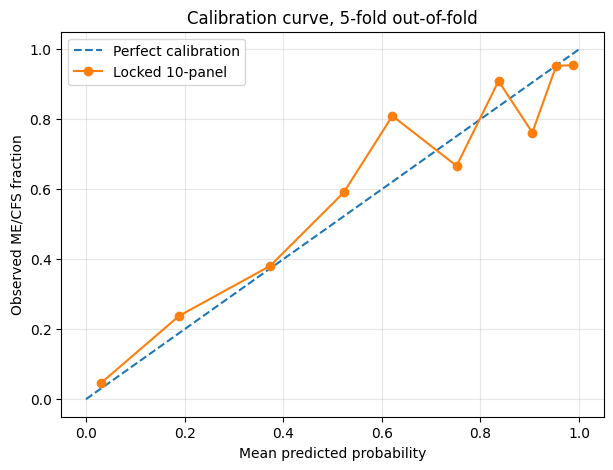

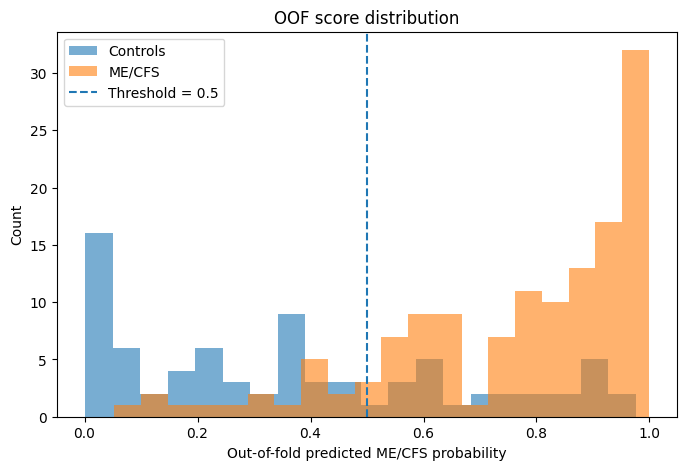

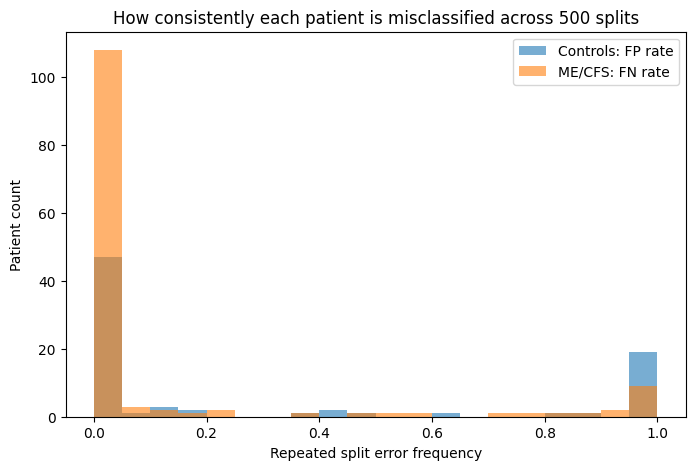

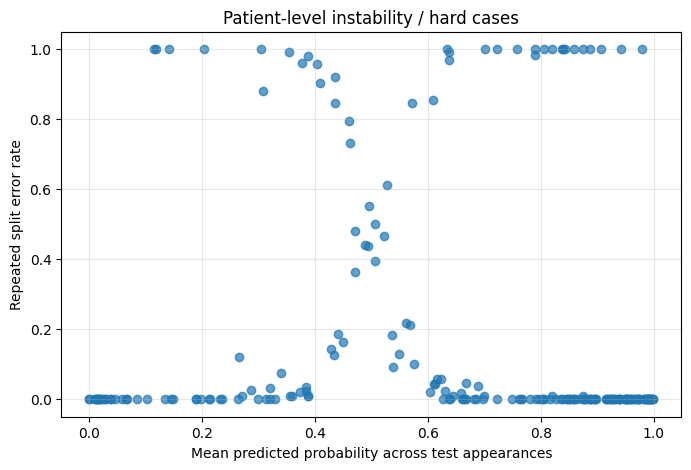

In [29]:
# =========================
# Locked 10-panel clinical diagnostics:
# Brier, calibration, FP/FN frequency across 500 splits
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    brier_score_loss,
    balanced_accuracy_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)
from sklearn.calibration import calibration_curve

# -------------------------
# Use locked 10 panel
# -------------------------

PANEL = LOCKED_PANEL

X_eval = X_panel[PANEL].copy()
y_eval = y.copy()

# preserve patient IDs if available
patient_ids = X_eval.index.astype(str)

N_SPLITS = 500
THRESHOLD = 0.50

split_rows = []
patient_rows = []

for seed in range(N_SPLITS):

    X_train, X_test, y_train, y_test = train_test_split(
        X_eval,
        y_eval,
        test_size=0.20,
        stratify=y_eval,
        random_state=seed
    )

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:, 1]
    preds = (probs >= THRESHOLD).astype(int)

    auc = roc_auc_score(y_test, probs)
    brier = brier_score_loss(y_test, probs)
    bal_acc = balanced_accuracy_score(y_test, preds)
    acc = accuracy_score(y_test, preds)

    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

    split_rows.append({
        "seed": seed,
        "auc": auc,
        "brier": brier,
        "accuracy": acc,
        "balanced_accuracy": bal_acc,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "sensitivity": sens,
        "specificity": spec,
        "PPV": ppv,
        "NPV": npv
    })

    temp = pd.DataFrame({
        "seed": seed,
        "patient_id": X_test.index.astype(str),
        "y_true": y_test.values,
        "prob": probs,
        "pred": preds
    })

    temp["correct"] = temp["y_true"] == temp["pred"]
    temp["FP"] = (temp["y_true"] == 0) & (temp["pred"] == 1)
    temp["FN"] = (temp["y_true"] == 1) & (temp["pred"] == 0)
    temp["TP"] = (temp["y_true"] == 1) & (temp["pred"] == 1)
    temp["TN"] = (temp["y_true"] == 0) & (temp["pred"] == 0)

    patient_rows.append(temp)

split_df = pd.DataFrame(split_rows)
patient_pred_df = pd.concat(patient_rows, ignore_index=True)

# -------------------------
# Split-level summary
# -------------------------

split_summary = split_df.agg({
    "auc": ["mean", "median", "std"],
    "brier": ["mean", "median", "std"],
    "accuracy": ["mean", "median", "std"],
    "balanced_accuracy": ["mean", "median", "std"],
    "sensitivity": ["mean", "median", "std"],
    "specificity": ["mean", "median", "std"],
    "PPV": ["mean", "median", "std"],
    "NPV": ["mean", "median", "std"],
    "FP": ["mean", "median", "std"],
    "FN": ["mean", "median", "std"]
}).T

split_summary["q05"] = split_df[split_summary.index].quantile(0.05)
split_summary["q95"] = split_df[split_summary.index].quantile(0.95)

print("===== 500-split performance summary =====")
display(split_summary)

# -------------------------
# Patient-level FP/FN frequency
# -------------------------

patient_summary = (
    patient_pred_df
    .groupby("patient_id")
    .agg(
        n_tested=("seed", "count"),
        y_true=("y_true", "first"),
        mean_prob=("prob", "mean"),
        median_prob=("prob", "median"),
        std_prob=("prob", "std"),
        min_prob=("prob", "min"),
        max_prob=("prob", "max"),
        correct_rate=("correct", "mean"),
        FP_rate=("FP", "mean"),
        FN_rate=("FN", "mean"),
        TP_rate=("TP", "mean"),
        TN_rate=("TN", "mean")
    )
    .reset_index()
)

patient_summary["error_rate"] = 1 - patient_summary["correct_rate"]

patient_summary = patient_summary.sort_values(
    ["error_rate", "FN_rate", "FP_rate"],
    ascending=False
)

print("\n===== Most consistently misclassified patients =====")
display(patient_summary.head(25))

print("\n===== Most consistent false negatives =====")
display(
    patient_summary[patient_summary["y_true"] == 1]
    .sort_values("FN_rate", ascending=False)
    .head(20)
)

print("\n===== Most consistent false positives =====")
display(
    patient_summary[patient_summary["y_true"] == 0]
    .sort_values("FP_rate", ascending=False)
    .head(20)
)

# -------------------------
# Out-of-fold calibration on full dataset
# -------------------------

oof_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probs = cross_val_predict(
    oof_pipe,
    X_eval,
    y_eval,
    cv=cv,
    method="predict_proba"
)[:, 1]

oof_preds = (oof_probs >= THRESHOLD).astype(int)

oof_auc = roc_auc_score(y_eval, oof_probs)
oof_brier = brier_score_loss(y_eval, oof_probs)
oof_bal_acc = balanced_accuracy_score(y_eval, oof_preds)

print("\n===== 5-fold out-of-fold clinical metrics =====")
print(f"OOF AUC              : {oof_auc:.3f}")
print(f"OOF Brier score      : {oof_brier:.3f}")
print(f"OOF balanced accuracy: {oof_bal_acc:.3f}")

prob_true, prob_pred = calibration_curve(
    y_eval,
    oof_probs,
    n_bins=10,
    strategy="quantile"
)

calibration_table = pd.DataFrame({
    "mean_predicted_probability": prob_pred,
    "observed_fraction_ME_CFS": prob_true,
    "absolute_calibration_error": np.abs(prob_true - prob_pred)
})

print("\n===== Calibration table =====")
display(calibration_table)

print(f"Mean absolute calibration error: {calibration_table['absolute_calibration_error'].mean():.3f}")

# -------------------------
# OOF score table
# -------------------------

oof_score_df = pd.DataFrame({
    "patient_id": X_eval.index.astype(str),
    "y_true": y_eval.values,
    "oof_prob": oof_probs,
    "oof_pred": oof_preds
})

oof_score_df["error_type"] = "correct"
oof_score_df.loc[(oof_score_df["y_true"] == 0) & (oof_score_df["oof_pred"] == 1), "error_type"] = "FP"
oof_score_df.loc[(oof_score_df["y_true"] == 1) & (oof_score_df["oof_pred"] == 0), "error_type"] = "FN"

print("\n===== Out-of-fold errors =====")
display(
    oof_score_df[oof_score_df["error_type"] != "correct"]
    .sort_values("oof_prob")
)

# -------------------------
# Plots
# -------------------------

plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred, prob_true, marker="o", label="Locked 10-panel")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed ME/CFS fraction")
plt.title("Calibration curve, 5-fold out-of-fold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(oof_probs[y_eval.values == 0], bins=20, alpha=0.6, label="Controls")
plt.hist(oof_probs[y_eval.values == 1], bins=20, alpha=0.6, label="ME/CFS")
plt.axvline(THRESHOLD, linestyle="--", label=f"Threshold = {THRESHOLD}")
plt.xlabel("Out-of-fold predicted ME/CFS probability")
plt.ylabel("Count")
plt.title("OOF score distribution")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(patient_summary[patient_summary["y_true"] == 0]["FP_rate"], bins=20, alpha=0.6, label="Controls: FP rate")
plt.hist(patient_summary[patient_summary["y_true"] == 1]["FN_rate"], bins=20, alpha=0.6, label="ME/CFS: FN rate")
plt.xlabel("Repeated split error frequency")
plt.ylabel("Patient count")
plt.title("How consistently each patient is misclassified across 500 splits")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    patient_summary["mean_prob"],
    patient_summary["error_rate"],
    alpha=0.7
)
plt.xlabel("Mean predicted probability across test appearances")
plt.ylabel("Repeated split error rate")
plt.title("Patient-level instability / hard cases")
plt.grid(alpha=0.3)
plt.show()

In [30]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'os', 're', 'itertools', 'warnings', 'Path', 'Counter', 'np', 'pd', 'plt', 'mannwhitneyu', 'expit', 'StratifiedKFold', 'cross_val_score', 'train_test_split', 'Pipeline', 'ColumnTransformer', 'StandardScaler', 'OneHotEncoder', 'SimpleImputer', 'SelectKBest', 'f_classif', 'LogisticRegression', 'roc_auc_score', 'BASE', 'META_PATH', 'METAB_PATH', 'QUEST_PATH', 'IMMUNE_PCT_PATH', 'IMMUNE_RES_PATH', 'KEGG_PATH', 'SPECIES_PATH', 'OUT_DIR', 'FINAL_DIR', 'RANDOM_STATE', '_i2', 'LOCKED_PANEL', '_2', '_i3', 'meta_raw', 'metab_raw', 'metab', 'tp1', 'meta_tp1', 'df', 'y', 'X_panel', '_i4', 'NB1_SCORE_CANDIDATES', 'score_path', 'score_df', 'required_score_cols', 'missing', '_i5', '_i6', 'score_meta', '_i7', 'numeric_cols', 'rows', 'c', 'temp', 'corr_df', '_

In [31]:
hard_fn = (
    patient_summary[
        (patient_summary["y_true"] == 1) &
        (patient_summary["FN_rate"] > 0.75)
    ]
)

print(len(hard_fn))
display(hard_fn)

14


,patient_id,n_tested,y_true,mean_prob,median_prob,std_prob,min_prob,max_prob,correct_rate,FP_rate,FN_rate,TP_rate,TN_rate,error_rate
19,115,120,1,0.141335,0.140449,0.023108,0.086870,0.203925,0.000000,0.0,1.000000,0.000000,0.0,1.000000
61,153,116,1,0.203552,0.198072,0.046045,0.101994,0.329535,0.000000,0.0,1.000000,0.000000,0.0,1.000000
73,164,105,1,0.304520,0.302210,0.053172,0.172658,0.426582,0.000000,0.0,1.000000,0.000000,0.0,1.000000
98,187,105,1,0.114783,0.106669,0.035889,0.035454,0.211116,0.000000,0.0,1.000000,0.000000,0.0,1.000000
211,97,93,1,0.119289,0.116901,0.044323,0.039105,0.258670,0.000000,0.0,1.000000,0.000000,0.0,1.000000
183,71,109,1,0.354519,0.348001,0.057254,0.205320,0.503569,0.009174,0.0,0.990826,0.009174,0.0,0.990826
10,107,99,1,0.387236,0.381431,0.053667,0.267269,0.530530,0.020202,0.0,0.979798,0.020202,0.0,0.979798
105,193,101,1,0.378088,0.380016,0.078249,0.186048,0.582894,0.039604,0.0,0.960396,0.039604,0.0,0.960396
23,119,98,1,0.404291,0.399237,0.057867,0.300223,0.560203,0.040816,0.0,0.959184,0.040816,0.0,0.959184
2,10,100,1,0.435672,0.432867,0.043535,0.339670,0.547305,0.080000,0.0,0.920000,0.080000,0.0,0.920000


Hard FN IDs: 14
other_MECFS      121
control           79
hard_FN_MECFS     14
Name: group, dtype: int64

===== Hard FN vs Other ME/CFS =====


,feature,group_A,group_B,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean_A_minus_B,cohen_d_A_minus_B,p_value,fdr_q
8,vanillylmandelate (VMA),hard_FN_MECFS,other_MECFS,14,121,1.554095,1.136517,1.412128,1.087349,0.417578,0.746360,0.004411,0.032914
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",hard_FN_MECFS,other_MECFS,14,121,1.118056,1.279360,1.167990,1.269256,-0.161304,-0.836442,0.006583,0.032914
6,3-(4-hydroxyphenyl)lactate,hard_FN_MECFS,other_MECFS,14,121,1.021009,0.808934,0.968676,0.738388,0.212075,0.660161,0.013993,0.046645
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),hard_FN_MECFS,other_MECFS,14,121,1.126382,1.482102,1.111410,1.439010,-0.355719,-0.702845,0.021938,0.054845
9,4-vinylguaiacol sulfate,hard_FN_MECFS,other_MECFS,14,121,0.253786,0.132347,0.070572,0.070572,0.121439,0.284101,0.057229,0.114457
2,N4-acetylcytidine,hard_FN_MECFS,other_MECFS,14,121,2.214672,2.567274,1.619260,2.296046,-0.352602,-0.178535,0.089877,0.135383
7,N-acetylglucosamine/N-acetylgalactosamine,hard_FN_MECFS,other_MECFS,14,121,0.741761,0.847544,0.720807,0.826731,-0.105783,-0.484622,0.094768,0.135383
5,N-palmitoyl-sphingosine (d18:1/16:0),hard_FN_MECFS,other_MECFS,14,121,1.187495,1.355368,1.188606,1.301122,-0.167873,-0.563450,0.151972,0.189965
4,1-methylurate,hard_FN_MECFS,other_MECFS,14,121,0.982297,0.594659,0.317513,0.194419,0.387639,0.272817,0.556007,0.617786
1,N-acetylglutamate,hard_FN_MECFS,other_MECFS,14,121,0.558398,0.597434,0.545302,0.569907,-0.039036,-0.261435,0.626148,0.626148



===== Hard FN vs Controls =====


,feature,group_A,group_B,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean_A_minus_B,cohen_d_A_minus_B,p_value,fdr_q
1,N-acetylglutamate,hard_FN_MECFS,control,14,79,0.558398,0.464753,0.545302,0.483475,0.093645,0.489188,0.096664,0.936713
4,1-methylurate,hard_FN_MECFS,control,14,79,0.982297,1.277664,0.317513,0.816740,-0.295366,-0.177677,0.195318,0.936713
5,N-palmitoyl-sphingosine (d18:1/16:0),hard_FN_MECFS,control,14,79,1.187495,1.132769,1.188606,1.095874,0.054726,0.229533,0.285076,0.936713
8,vanillylmandelate (VMA),hard_FN_MECFS,control,14,79,1.554095,1.392091,1.412128,1.384030,0.162004,0.270222,0.572728,0.936713
9,4-vinylguaiacol sulfate,hard_FN_MECFS,control,14,79,0.253786,0.451353,0.070572,0.070572,-0.197567,-0.261621,0.619998,0.936713
7,N-acetylglucosamine/N-acetylgalactosamine,hard_FN_MECFS,control,14,79,0.741761,0.730423,0.720807,0.704405,0.011338,0.061146,0.647956,0.936713
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",hard_FN_MECFS,control,14,79,1.118056,1.144173,1.167990,1.138470,-0.026117,-0.138587,0.655699,0.936713
6,3-(4-hydroxyphenyl)lactate,hard_FN_MECFS,control,14,79,1.021009,1.018901,0.968676,0.987138,0.002108,0.006568,0.850867,0.965721
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),hard_FN_MECFS,control,14,79,1.126382,1.145679,1.111410,1.087442,-0.019297,-0.047297,0.893169,0.965721
2,N4-acetylcytidine,hard_FN_MECFS,control,14,79,2.214672,1.726970,1.619260,1.591924,0.487702,0.281388,0.965721,0.965721



===== Other ME/CFS vs Controls =====


,feature,group_A,group_B,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean_A_minus_B,cohen_d_A_minus_B,p_value,fdr_q
6,3-(4-hydroxyphenyl)lactate,other_MECFS,control,121,79,0.808934,1.018901,0.738388,0.987138,-0.209967,-0.691652,1.378161e-07,0.000001
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",other_MECFS,control,121,79,1.279360,1.144173,1.269256,1.138470,0.135187,0.727670,1.503291e-06,0.000008
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),other_MECFS,control,121,79,1.482102,1.145679,1.439010,1.087442,0.336422,0.712668,3.511868e-06,0.000012
5,N-palmitoyl-sphingosine (d18:1/16:0),other_MECFS,control,121,79,1.355368,1.132769,1.301122,1.095874,0.222599,0.693497,1.154817e-05,0.000026
2,N4-acetylcytidine,other_MECFS,control,121,79,2.567274,1.726970,2.296046,1.591924,0.840304,0.651143,1.302024e-05,0.000026
9,4-vinylguaiacol sulfate,other_MECFS,control,121,79,0.132347,0.451353,0.070572,0.070572,-0.319006,-0.455014,7.281998e-05,0.000118
8,vanillylmandelate (VMA),other_MECFS,control,121,79,1.136517,1.392091,1.087349,1.384030,-0.255575,-0.614597,8.238356e-05,0.000118
1,N-acetylglutamate,other_MECFS,control,121,79,0.597434,0.464753,0.569907,0.483475,0.132681,0.620295,1.313239e-04,0.000147
4,1-methylurate,other_MECFS,control,121,79,0.594659,1.277664,0.194419,0.816740,-0.683005,-0.559349,1.321711e-04,0.000147
7,N-acetylglucosamine/N-acetylgalactosamine,other_MECFS,control,121,79,0.847544,0.730423,0.826731,0.704405,0.117121,0.461462,8.413398e-04,0.000841



Locked panel features present: 10 / 10

===== Locked 10 hard-FN comparison =====


,feature,hard_FN_mean,other_MECFS_mean,control_mean,hard_FN_median,other_MECFS_median,control_median,hard_vs_other_p,hard_minus_other,hard_minus_control,hard_vs_other_fdr_q
8,vanillylmandelate (VMA),1.554095,1.136517,1.392091,1.412128,1.087349,1.384030,0.004411,0.417578,0.162004,0.032914
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",1.118056,1.279360,1.144173,1.167990,1.269256,1.138470,0.006583,-0.161304,-0.026117,0.032914
6,3-(4-hydroxyphenyl)lactate,1.021009,0.808934,1.018901,0.968676,0.738388,0.987138,0.013993,0.212075,0.002108,0.046645
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),1.126382,1.482102,1.145679,1.111410,1.439010,1.087442,0.021938,-0.355719,-0.019297,0.054845
9,4-vinylguaiacol sulfate,0.253786,0.132347,0.451353,0.070572,0.070572,0.070572,0.057229,0.121439,-0.197567,0.114457
2,N4-acetylcytidine,2.214672,2.567274,1.726970,1.619260,2.296046,1.591924,0.089877,-0.352602,0.487702,0.135383
7,N-acetylglucosamine/N-acetylgalactosamine,0.741761,0.847544,0.730423,0.720807,0.826731,0.704405,0.094768,-0.105783,0.011338,0.135383
5,N-palmitoyl-sphingosine (d18:1/16:0),1.187495,1.355368,1.132769,1.188606,1.301122,1.095874,0.151972,-0.167873,0.054726,0.189965
4,1-methylurate,0.982297,0.594659,1.277664,0.317513,0.194419,0.816740,0.556007,0.387639,-0.295366,0.617786
1,N-acetylglutamate,0.558398,0.597434,0.464753,0.545302,0.569907,0.483475,0.626148,-0.039036,0.093645,0.626148


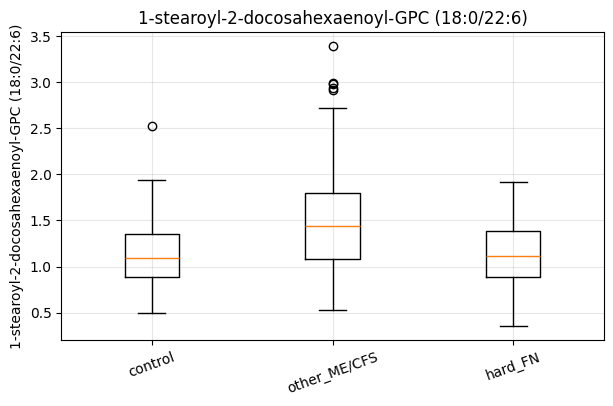

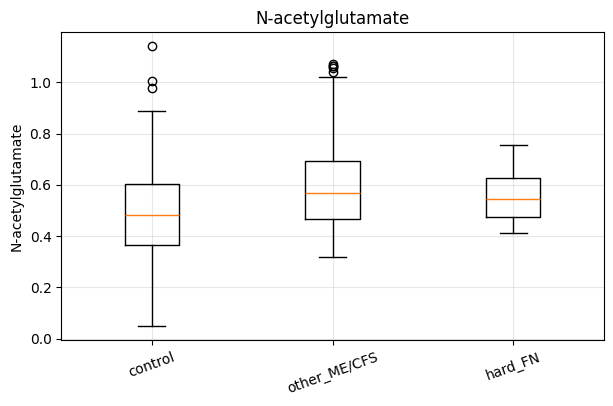

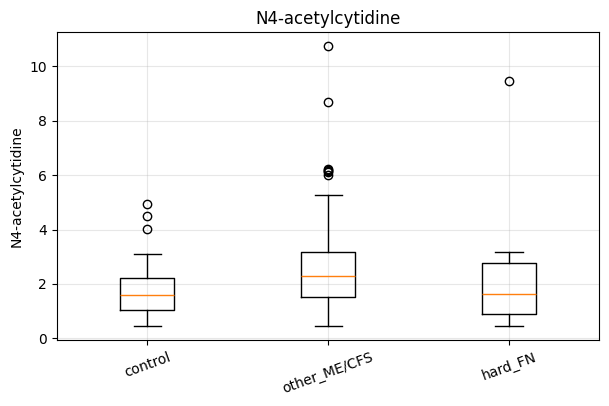

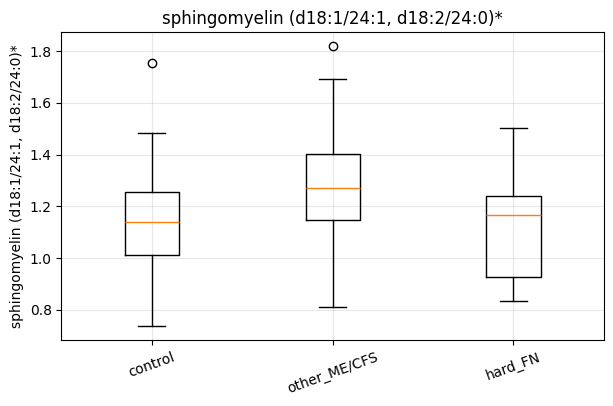

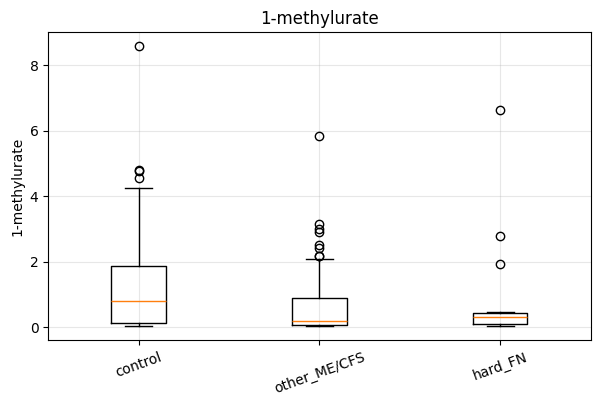

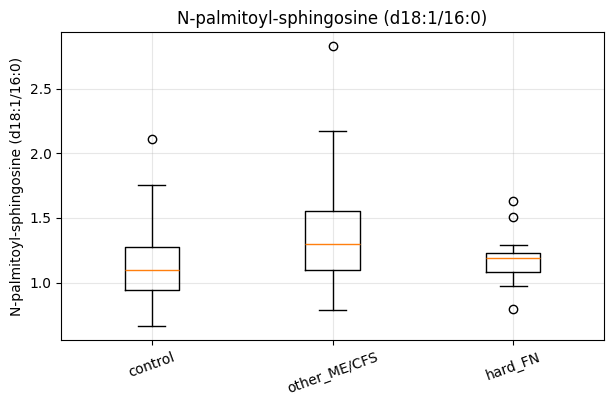

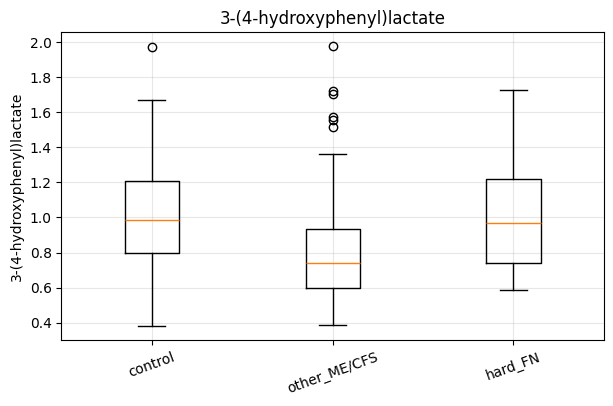

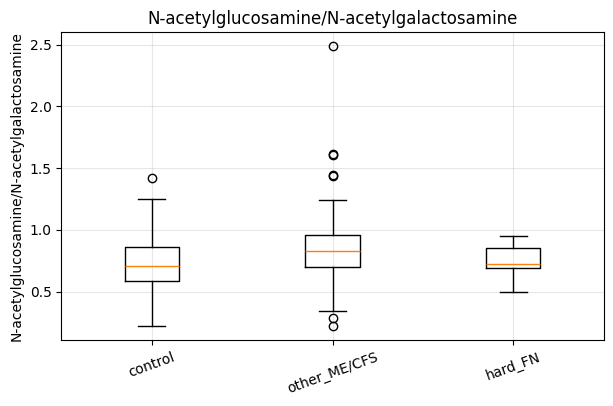

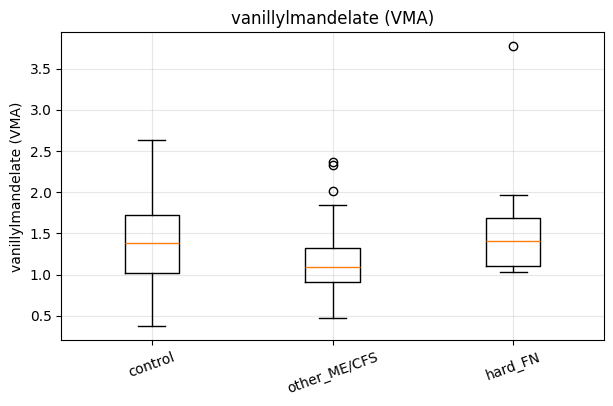

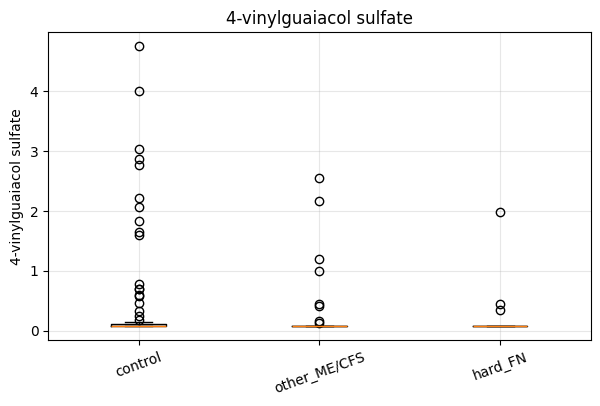

In [32]:
# =========================
# Hard FN metabolome/locked-panel comparison using X_panel directly
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# -------------------------
# Use same data source as model
# -------------------------

X_metab = X_panel.copy()
X_metab.index = X_metab.index.astype(str)

y_metab = y.copy()
y_metab.index = y_metab.index.astype(str)

patient_summary_fixed = patient_summary.copy()
patient_summary_fixed["patient_id"] = patient_summary_fixed["patient_id"].astype(str)

hard_fn_ids = (
    patient_summary_fixed[
        (patient_summary_fixed["y_true"] == 1) &
        (patient_summary_fixed["FN_rate"] > 0.75)
    ]["patient_id"]
    .astype(str)
    .tolist()
)

print("Hard FN IDs:", len(hard_fn_ids))

group_df = pd.DataFrame({
    "patient_id": X_metab.index,
    "label": y_metab.loc[X_metab.index].values
})

group_df["group"] = "control"
group_df.loc[group_df["label"] == 1, "group"] = "other_MECFS"
group_df.loc[group_df["patient_id"].isin(hard_fn_ids), "group"] = "hard_FN_MECFS"

print(group_df["group"].value_counts())

hard_ids = group_df[group_df["group"] == "hard_FN_MECFS"]["patient_id"].tolist()
other_ids = group_df[group_df["group"] == "other_MECFS"]["patient_id"].tolist()
control_ids = group_df[group_df["group"] == "control"]["patient_id"].tolist()

# -------------------------
# Compare groups
# -------------------------

def compare_groups(X, ids_a, ids_b, name_a, name_b):
    rows = []

    for feature in X.columns:
        a = X.loc[ids_a, feature].dropna()
        b = X.loc[ids_b, feature].dropna()

        if len(a) < 3 or len(b) < 3:
            continue

        stat, p = mannwhitneyu(a, b, alternative="two-sided")

        pooled_sd = np.sqrt((a.std()**2 + b.std()**2) / 2)
        cohen_d = (a.mean() - b.mean()) / pooled_sd if pooled_sd != 0 else np.nan

        rows.append({
            "feature": feature,
            "group_A": name_a,
            "group_B": name_b,
            "n_A": len(a),
            "n_B": len(b),
            "mean_A": a.mean(),
            "mean_B": b.mean(),
            "median_A": a.median(),
            "median_B": b.median(),
            "delta_mean_A_minus_B": a.mean() - b.mean(),
            "cohen_d_A_minus_B": cohen_d,
            "p_value": p
        })

    res = pd.DataFrame(rows)

    if len(res) > 0:
        res["fdr_q"] = multipletests(res["p_value"], method="fdr_bh")[1]
        res = res.sort_values(["fdr_q", "p_value"])

    return res

hard_vs_other = compare_groups(
    X_metab, hard_ids, other_ids,
    "hard_FN_MECFS", "other_MECFS"
)

hard_vs_control = compare_groups(
    X_metab, hard_ids, control_ids,
    "hard_FN_MECFS", "control"
)

other_vs_control = compare_groups(
    X_metab, other_ids, control_ids,
    "other_MECFS", "control"
)

print("\n===== Hard FN vs Other ME/CFS =====")
display(hard_vs_other.head(25))

print("\n===== Hard FN vs Controls =====")
display(hard_vs_control.head(25))

print("\n===== Other ME/CFS vs Controls =====")
display(other_vs_control.head(25))

# -------------------------
# Locked 10 only summary
# -------------------------

locked_present = [f for f in LOCKED_PANEL if f in X_metab.columns]
print(f"\nLocked panel features present: {len(locked_present)} / {len(LOCKED_PANEL)}")

locked10_summary = []

for feature in locked_present:
    hard_vals = X_metab.loc[hard_ids, feature]
    other_vals = X_metab.loc[other_ids, feature]
    control_vals = X_metab.loc[control_ids, feature]

    stat, p = mannwhitneyu(hard_vals, other_vals, alternative="two-sided")

    locked10_summary.append({
        "feature": feature,
        "hard_FN_mean": hard_vals.mean(),
        "other_MECFS_mean": other_vals.mean(),
        "control_mean": control_vals.mean(),
        "hard_FN_median": hard_vals.median(),
        "other_MECFS_median": other_vals.median(),
        "control_median": control_vals.median(),
        "hard_vs_other_p": p,
        "hard_minus_other": hard_vals.mean() - other_vals.mean(),
        "hard_minus_control": hard_vals.mean() - control_vals.mean()
    })

locked10_summary = pd.DataFrame(locked10_summary)

if len(locked10_summary) > 0:
    locked10_summary["hard_vs_other_fdr_q"] = multipletests(
        locked10_summary["hard_vs_other_p"],
        method="fdr_bh"
    )[1]

    locked10_summary = locked10_summary.sort_values("hard_vs_other_p")

print("\n===== Locked 10 hard-FN comparison =====")
display(locked10_summary)

# -------------------------
# Boxplots for locked 10
# -------------------------

for feature in locked_present:
    data = [
        X_metab.loc[control_ids, feature].dropna(),
        X_metab.loc[other_ids, feature].dropna(),
        X_metab.loc[hard_ids, feature].dropna()
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data, labels=["control", "other_ME/CFS", "hard_FN"])
    plt.ylabel(feature)
    plt.title(feature)
    plt.xticks(rotation=20)
    plt.grid(alpha=0.3)
    plt.show()

In [33]:
# =========================
# Remove persistent hard-FN patients
# Re-run 500-split robustness
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# -------------------------
# Identify hard FN patients
# -------------------------

hard_fn_ids = (
    patient_summary[
        (patient_summary["y_true"] == 1) &
        (patient_summary["FN_rate"] > 0.75)
    ]["patient_id"]
    .astype(str)
    .tolist()
)

print(f"Removing {len(hard_fn_ids)} hard-FN patients")

# -------------------------
# Build filtered dataset
# -------------------------

X_filtered = X_panel.copy()
y_filtered = y.copy()

X_filtered.index = X_filtered.index.astype(str)
y_filtered.index = y_filtered.index.astype(str)

keep_ids = [
    idx for idx in X_filtered.index
    if idx not in hard_fn_ids
]

X_filtered = X_filtered.loc[keep_ids]
y_filtered = y_filtered.loc[keep_ids]

print("\nRemaining cohort:")
print(pd.Series(y_filtered).value_counts())

# -------------------------
# Re-run robustness
# -------------------------

N_SPLITS = 500
aucs = []

for seed in range(N_SPLITS):

    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered[LOCKED_PANEL],
        y_filtered,
        test_size=0.20,
        stratify=y_filtered,
        random_state=seed
    )

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    pipe.fit(X_train, y_train)

    probs = pipe.predict_proba(X_test)[:, 1]

    aucs.append(
        roc_auc_score(y_test, probs)
    )

aucs = np.array(aucs)

print("\n===== Hard-FN Removed =====")
print(f"Mean AUC   : {aucs.mean():.3f}")
print(f"Median AUC : {np.median(aucs):.3f}")
print(f"Std AUC    : {aucs.std():.3f}")
print(f"5th pct    : {np.quantile(aucs, 0.05):.3f}")
print(f"95th pct   : {np.quantile(aucs, 0.95):.3f}")

Removing 14 hard-FN patients

Remaining cohort:
1    121
0     79
Name: study_ptorhc, dtype: int64

===== Hard-FN Removed =====
Mean AUC   : 0.907
Median AUC : 0.911
Std AUC    : 0.045
5th pct    : 0.831
95th pct   : 0.974


In [34]:
hard_fp = (
    patient_summary[
        (patient_summary["y_true"] == 0) &
        (patient_summary["FP_rate"] > 0.75)
    ]
)

print(len(hard_fp))

display(
    hard_fp[
        ["patient_id","mean_prob","FP_rate","error_rate"]
    ]
    .sort_values("FP_rate", ascending=False)
)

21


,patient_id,mean_prob,FP_rate,error_rate
37,131,0.758579,1.000000,1.000000
95,184,0.633148,1.000000,1.000000
199,86,0.978460,1.000000,1.000000
190,78,0.858469,1.000000,1.000000
185,73,0.907174,1.000000,1.000000
166,56,0.722034,1.000000,1.000000
155,46,0.700320,1.000000,1.000000
44,138,0.875055,1.000000,1.000000
108,196,0.819152,1.000000,1.000000
86,176,0.789852,1.000000,1.000000


In [35]:
print(
    patient_summary[
        patient_summary["y_true"] == 0
    ]["FP_rate"].describe()
)

print(
    patient_summary[
        patient_summary["y_true"] == 1
    ]["FN_rate"].describe()
)

count    79.000000
mean      0.303504
std       0.428215
min       0.000000
25%       0.000000
50%       0.009091
75%       0.850565
max       1.000000
Name: FP_rate, dtype: float64
count    135.000000
mean       0.127398
std        0.299473
min        0.000000
25%        0.000000
50%        0.000000
75%        0.014031
max        1.000000
Name: FN_rate, dtype: float64


In [36]:
len(patient_summary[
    (patient_summary["y_true"] == 0) &
    (patient_summary["FP_rate"] > 0.75)
])


21

In [37]:

len(patient_summary[
    (patient_summary["y_true"] == 0) &
    (patient_summary["FP_rate"] > 0.90)
])


19

In [38]:

len(patient_summary[
    (patient_summary["y_true"] == 0) &
    (patient_summary["FP_rate"] == 1.0)
])

16

In [39]:
# =========================
# Aggregate FN / FP / TN / TP frequencies
# across all 500 splits
# =========================

agg = (
    patient_pred_df
    .groupby(["patient_id", "y_true"])
    .agg(
        n_tested=("seed", "count"),
        TP=("TP", "sum"),
        TN=("TN", "sum"),
        FP=("FP", "sum"),
        FN=("FN", "sum"),
        mean_prob=("prob", "mean")
    )
    .reset_index()
)

agg["TP_rate"] = agg["TP"] / agg["n_tested"]
agg["TN_rate"] = agg["TN"] / agg["n_tested"]
agg["FP_rate"] = agg["FP"] / agg["n_tested"]
agg["FN_rate"] = agg["FN"] / agg["n_tested"]

print("===== ME/CFS patients =====")
display(
    agg[agg["y_true"] == 1]
    .sort_values("FN_rate", ascending=False)
    .head(25)
)

print("\n===== Controls =====")
display(
    agg[agg["y_true"] == 0]
    .sort_values("FP_rate", ascending=False)
    .head(25)
)

print("\n===== Global totals across all test appearances =====")

total_tp = agg["TP"].sum()
total_tn = agg["TN"].sum()
total_fp = agg["FP"].sum()
total_fn = agg["FN"].sum()

print(f"TP = {total_tp}")
print(f"TN = {total_tn}")
print(f"FP = {total_fp}")
print(f"FN = {total_fn}")

print("\n===== Aggregate performance =====")

sens = total_tp / (total_tp + total_fn)
spec = total_tn / (total_tn + total_fp)

print(f"Sensitivity = {sens:.3f}")
print(f"Specificity = {spec:.3f}")

print("\n===== Persistent patients =====")

print(
    "FN_rate > 0.75:",
    len(agg[(agg.y_true == 1) & (agg.FN_rate > 0.75)])
)

print(
    "FP_rate > 0.75:",
    len(agg[(agg.y_true == 0) & (agg.FP_rate > 0.75)])
)

print(
    "FN_rate == 1.0:",
    len(agg[(agg.y_true == 1) & (agg.FN_rate == 1.0)])
)

print(
    "FP_rate == 1.0:",
    len(agg[(agg.y_true == 0) & (agg.FP_rate == 1.0)])
)

===== ME/CFS patients =====


,patient_id,y_true,n_tested,TP,TN,FP,FN,mean_prob,TP_rate,TN_rate,FP_rate,FN_rate
61,153,1,116,0,0,0,116,0.203552,0.000000,0.0,0.0,1.000000
19,115,1,120,0,0,0,120,0.141335,0.000000,0.0,0.0,1.000000
73,164,1,105,0,0,0,105,0.304520,0.000000,0.0,0.0,1.000000
211,97,1,93,0,0,0,93,0.119289,0.000000,0.0,0.0,1.000000
98,187,1,105,0,0,0,105,0.114783,0.000000,0.0,0.0,1.000000
183,71,1,109,1,0,0,108,0.354519,0.009174,0.0,0.0,0.990826
10,107,1,99,2,0,0,97,0.387236,0.020202,0.0,0.0,0.979798
105,193,1,101,4,0,0,97,0.378088,0.039604,0.0,0.0,0.960396
23,119,1,98,4,0,0,94,0.404291,0.040816,0.0,0.0,0.959184
2,10,1,100,8,0,0,92,0.435672,0.080000,0.0,0.0,0.920000



===== Controls =====


,patient_id,y_true,n_tested,TP,TN,FP,FN,mean_prob,TP_rate,TN_rate,FP_rate,FN_rate
37,131,0,96,0,0,96,0,0.758579,0.0,0.000000,1.000000,0.0
44,138,0,88,0,0,88,0,0.875055,0.0,0.000000,1.000000,0.0
86,176,0,101,0,0,101,0,0.789852,0.0,0.000000,1.000000,0.0
190,78,0,115,0,0,115,0,0.858469,0.0,0.000000,1.000000,0.0
69,160,0,104,0,0,104,0,0.842880,0.0,0.000000,1.000000,0.0
60,152,0,96,0,0,96,0,0.887887,0.0,0.000000,1.000000,0.0
56,149,0,92,0,0,92,0,0.941825,0.0,0.000000,1.000000,0.0
95,184,0,90,0,0,90,0,0.633148,0.0,0.000000,1.000000,0.0
51,144,0,98,0,0,98,0,0.837808,0.0,0.000000,1.000000,0.0
49,142,0,89,0,0,89,0,0.804884,0.0,0.000000,1.000000,0.0



===== Global totals across all test appearances =====
TP = 11758
TN = 5580
FP = 2420
FN = 1742

===== Aggregate performance =====
Sensitivity = 0.871
Specificity = 0.698

===== Persistent patients =====
FN_rate > 0.75: 14
FP_rate > 0.75: 21
FN_rate == 1.0: 5
FP_rate == 1.0: 16


Hard FP controls: 21
ME_CFS             135
other_control       58
hard_FP_control     21
Name: group, dtype: int64

===== Hard FP controls vs Other controls =====


,feature,group_A,group_B,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean_A_minus_B,cohen_d_A_minus_B,p_value,fdr_q
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),hard_FP_control,other_control,21,58,1.459339,1.032113,1.447557,1.035600,0.427225,1.237638,0.000017,0.000171
6,3-(4-hydroxyphenyl)lactate,hard_FP_control,other_control,21,58,0.806211,1.095909,0.782641,1.067353,-0.289698,-1.026275,0.000076,0.000381
4,1-methylurate,hard_FP_control,other_control,21,58,0.506856,1.556749,0.116026,1.249085,-1.049893,-0.837533,0.000218,0.000726
9,4-vinylguaiacol sulfate,hard_FP_control,other_control,21,58,0.070572,0.589223,0.070572,0.070572,-0.518651,-0.689940,0.001686,0.004215
5,N-palmitoyl-sphingosine (d18:1/16:0),hard_FP_control,other_control,21,58,1.257880,1.087470,1.205277,1.074263,0.170411,0.611177,0.030041,0.052066
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",hard_FP_control,other_control,21,58,1.225783,1.114624,1.193343,1.117704,0.111159,0.619995,0.035469,0.052066
2,N4-acetylcytidine,hard_FP_control,other_control,21,58,2.180367,1.562809,2.086175,1.421810,0.617558,0.652872,0.036446,0.052066
8,vanillylmandelate (VMA),hard_FP_control,other_control,21,58,1.261650,1.439320,1.281828,1.452090,-0.177670,-0.377198,0.177550,0.221938
1,N-acetylglutamate,hard_FP_control,other_control,21,58,0.536779,0.438675,0.504433,0.456570,0.098104,0.441919,0.245546,0.272829
7,N-acetylglucosamine/N-acetylgalactosamine,hard_FP_control,other_control,21,58,0.736249,0.728314,0.767447,0.691518,0.007935,0.034342,0.339889,0.339889



===== Hard FP controls vs ME/CFS =====


,feature,group_A,group_B,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean_A_minus_B,cohen_d_A_minus_B,p_value,fdr_q
1,N-acetylglutamate,hard_FP_control,ME_CFS,21,135,0.536779,0.593386,0.504433,0.566646,-0.056607,-0.330444,0.093517,0.511300
9,4-vinylguaiacol sulfate,hard_FP_control,ME_CFS,21,135,0.070572,0.144941,0.070572,0.070572,-0.074369,-0.303796,0.178494,0.511300
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",hard_FP_control,ME_CFS,21,135,1.225783,1.262632,1.193343,1.264583,-0.036849,-0.192200,0.251171,0.511300
4,1-methylurate,hard_FP_control,ME_CFS,21,135,0.506856,0.634858,0.116026,0.197275,-0.128002,-0.143571,0.271252,0.511300
7,N-acetylglucosamine/N-acetylgalactosamine,hard_FP_control,ME_CFS,21,135,0.736249,0.836574,0.767447,0.817348,-0.100325,-0.394999,0.272124,0.511300
8,vanillylmandelate (VMA),hard_FP_control,ME_CFS,21,135,1.261650,1.179821,1.281828,1.135967,0.081829,0.180186,0.321325,0.511300
2,N4-acetylcytidine,hard_FP_control,ME_CFS,21,135,2.180367,2.530707,2.086175,2.253805,-0.350340,-0.244416,0.369034,0.511300
5,N-palmitoyl-sphingosine (d18:1/16:0),hard_FP_control,ME_CFS,21,135,1.257880,1.337959,1.205277,1.246575,-0.080079,-0.236472,0.409040,0.511300
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),hard_FP_control,ME_CFS,21,135,1.459339,1.445212,1.447557,1.402103,0.014126,0.029029,0.716258,0.795842
6,3-(4-hydroxyphenyl)lactate,hard_FP_control,ME_CFS,21,135,0.806211,0.830927,0.782641,0.752692,-0.024716,-0.081384,0.983430,0.983430



===== Other controls vs ME/CFS =====


,feature,group_A,group_B,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean_A_minus_B,cohen_d_A_minus_B,p_value,fdr_q
6,3-(4-hydroxyphenyl)lactate,other_control,ME_CFS,58,135,1.095909,0.830927,1.067353,0.752692,0.264982,0.906788,2.122819e-09,2.122819e-08
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),other_control,ME_CFS,58,135,1.032113,1.445212,1.035600,1.402103,-0.413099,-0.939192,7.523217e-08,3.761609e-07
4,1-methylurate,other_control,ME_CFS,58,135,1.556749,0.634858,1.249085,0.197275,0.921890,0.691313,1.669962e-07,5.566539e-07
9,4-vinylguaiacol sulfate,other_control,ME_CFS,58,135,0.589223,0.144941,0.070572,0.070572,0.444282,0.561964,1.085598e-06,2.713995e-06
5,N-palmitoyl-sphingosine (d18:1/16:0),other_control,ME_CFS,58,135,1.087470,1.337959,1.074263,1.246575,-0.250489,-0.831791,1.884044e-06,3.768088e-06
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",other_control,ME_CFS,58,135,1.114624,1.262632,1.117704,1.264583,-0.148008,-0.803409,3.013205e-06,5.022008e-06
2,N4-acetylcytidine,other_control,ME_CFS,58,135,1.562809,2.530707,1.421810,2.253805,-0.967899,-0.752506,9.497694e-06,1.356813e-05
1,N-acetylglutamate,other_control,ME_CFS,58,135,0.438675,0.593386,0.456570,0.566646,-0.154711,-0.695514,1.296777e-04,1.620971e-04
8,vanillylmandelate (VMA),other_control,ME_CFS,58,135,1.439320,1.179821,1.452090,1.135967,0.259499,0.589584,1.832933e-04,2.036592e-04
7,N-acetylglucosamine/N-acetylgalactosamine,other_control,ME_CFS,58,135,0.728314,0.836574,0.691518,0.817348,-0.108260,-0.437602,1.037902e-03,1.037902e-03



===== Locked 10: hard FP control profile =====


,feature,hard_FP_control_mean,other_control_mean,ME_CFS_mean,hard_FP_control_median,other_control_median,ME_CFS_median,hardFP_minus_otherControl,hardFP_minus_MECFS,p_hardFP_vs_otherControl,p_hardFP_vs_MECFS,q_hardFP_vs_otherControl,q_hardFP_vs_MECFS
0,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),1.459339,1.032113,1.445212,1.447557,1.035600,1.402103,0.427225,0.014126,0.000017,0.716258,0.000171,0.795842
6,3-(4-hydroxyphenyl)lactate,0.806211,1.095909,0.830927,0.782641,1.067353,0.752692,-0.289698,-0.024716,0.000076,0.983430,0.000381,0.983430
4,1-methylurate,0.506856,1.556749,0.634858,0.116026,1.249085,0.197275,-1.049893,-0.128002,0.000218,0.271252,0.000726,0.511300
9,4-vinylguaiacol sulfate,0.070572,0.589223,0.144941,0.070572,0.070572,0.070572,-0.518651,-0.074369,0.001686,0.178494,0.004215,0.511300
5,N-palmitoyl-sphingosine (d18:1/16:0),1.257880,1.087470,1.337959,1.205277,1.074263,1.246575,0.170411,-0.080079,0.030041,0.409040,0.052066,0.511300
3,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",1.225783,1.114624,1.262632,1.193343,1.117704,1.264583,0.111159,-0.036849,0.035469,0.251171,0.052066,0.511300
2,N4-acetylcytidine,2.180367,1.562809,2.530707,2.086175,1.421810,2.253805,0.617558,-0.350340,0.036446,0.369034,0.052066,0.511300
8,vanillylmandelate (VMA),1.261650,1.439320,1.179821,1.281828,1.452090,1.135967,-0.177670,0.081829,0.177550,0.321325,0.221938,0.511300
1,N-acetylglutamate,0.536779,0.438675,0.593386,0.504433,0.456570,0.566646,0.098104,-0.056607,0.245546,0.093517,0.272829,0.511300
7,N-acetylglucosamine/N-acetylgalactosamine,0.736249,0.728314,0.836574,0.767447,0.691518,0.817348,0.007935,-0.100325,0.339889,0.272124,0.339889,0.511300


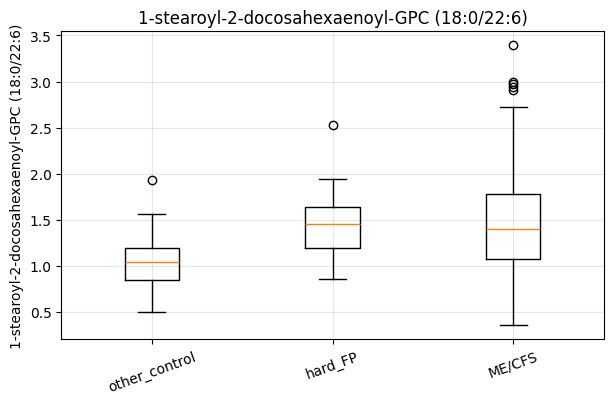

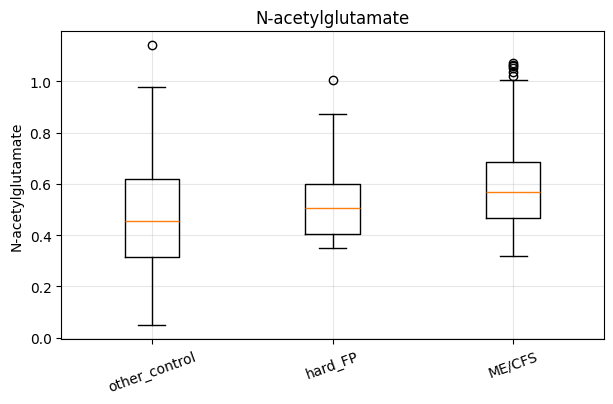

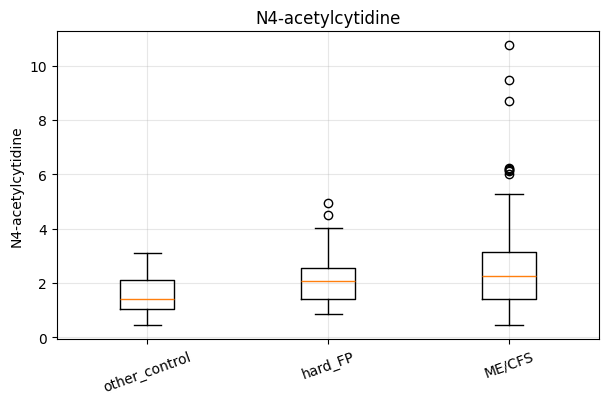

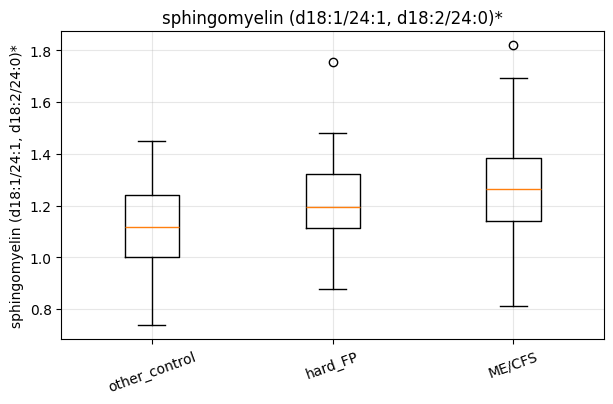

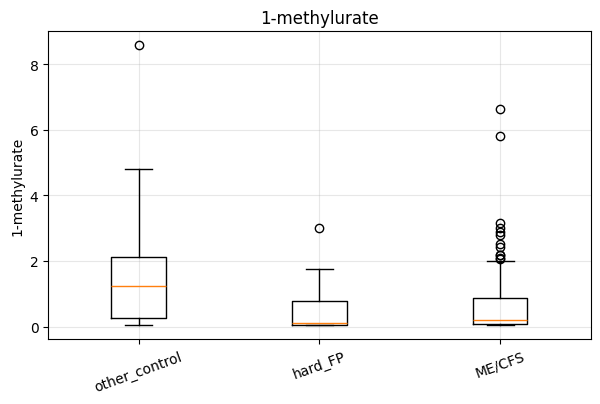

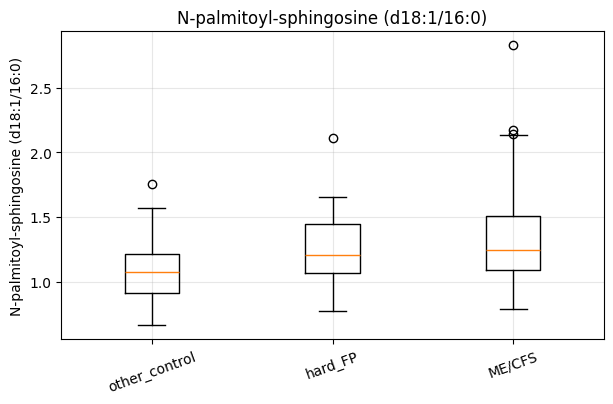

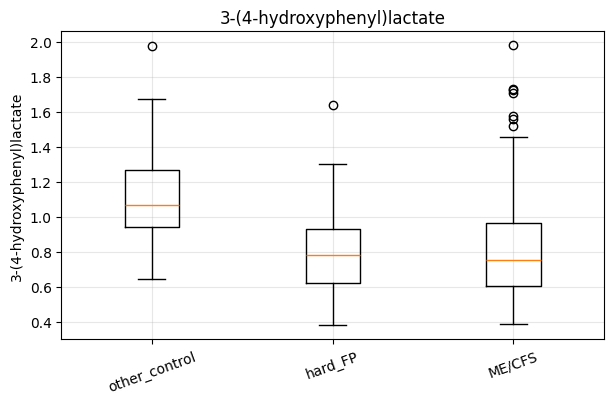

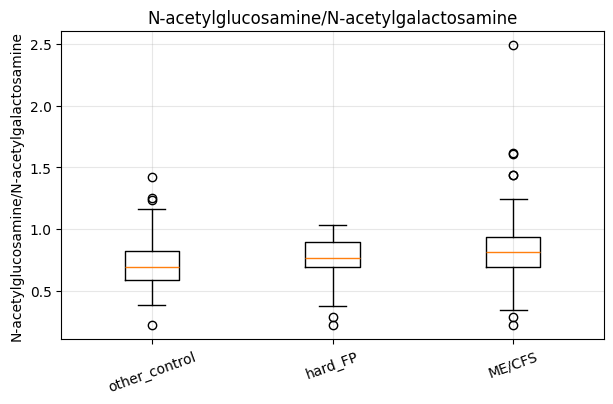

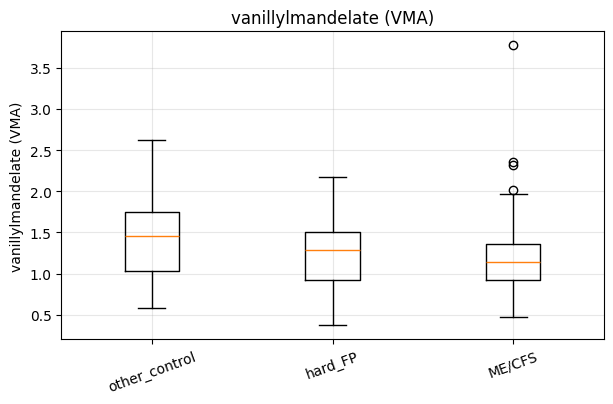

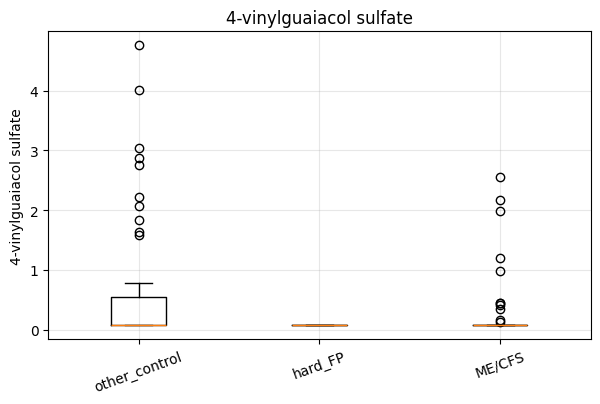

In [40]:
# =========================
# Hard FP controls metabolome comparison
# hard FP controls vs other controls vs ME/CFS
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# -------------------------
# Define hard FP controls
# -------------------------

HARD_FP_CUTOFF = 0.75   # change to 1.0 if you only want always-FP controls

hard_fp_ids = (
    patient_summary[
        (patient_summary["y_true"] == 0) &
        (patient_summary["FP_rate"] > HARD_FP_CUTOFF)
    ]["patient_id"]
    .astype(str)
    .tolist()
)

print(f"Hard FP controls: {len(hard_fp_ids)}")

# -------------------------
# Use same model matrix
# -------------------------

X_metab = X_panel.copy()
X_metab.index = X_metab.index.astype(str)

y_metab = y.copy()
y_metab.index = y_metab.index.astype(str)

group_df = pd.DataFrame({
    "patient_id": X_metab.index,
    "label": y_metab.loc[X_metab.index].values
})

group_df["group"] = "other_control"
group_df.loc[group_df["label"] == 1, "group"] = "ME_CFS"
group_df.loc[group_df["patient_id"].isin(hard_fp_ids), "group"] = "hard_FP_control"

print(group_df["group"].value_counts())

hard_fp = group_df[group_df["group"] == "hard_FP_control"]["patient_id"].tolist()
other_control = group_df[group_df["group"] == "other_control"]["patient_id"].tolist()
mecfs = group_df[group_df["group"] == "ME_CFS"]["patient_id"].tolist()

# -------------------------
# Group comparison helper
# -------------------------

def compare_groups(X, ids_a, ids_b, name_a, name_b):
    rows = []

    for feature in X.columns:
        a = X.loc[ids_a, feature].dropna()
        b = X.loc[ids_b, feature].dropna()

        if len(a) < 3 or len(b) < 3:
            continue

        stat, p = mannwhitneyu(a, b, alternative="two-sided")

        pooled_sd = np.sqrt((a.std()**2 + b.std()**2) / 2)
        cohen_d = (a.mean() - b.mean()) / pooled_sd if pooled_sd != 0 else np.nan

        rows.append({
            "feature": feature,
            "group_A": name_a,
            "group_B": name_b,
            "n_A": len(a),
            "n_B": len(b),
            "mean_A": a.mean(),
            "mean_B": b.mean(),
            "median_A": a.median(),
            "median_B": b.median(),
            "delta_mean_A_minus_B": a.mean() - b.mean(),
            "cohen_d_A_minus_B": cohen_d,
            "p_value": p
        })

    res = pd.DataFrame(rows)

    if len(res) > 0:
        res["fdr_q"] = multipletests(res["p_value"], method="fdr_bh")[1]
        res = res.sort_values(["fdr_q", "p_value"])

    return res

# -------------------------
# Main comparisons
# -------------------------

hardfp_vs_otherctrl = compare_groups(
    X_metab,
    hard_fp,
    other_control,
    "hard_FP_control",
    "other_control"
)

hardfp_vs_mecfs = compare_groups(
    X_metab,
    hard_fp,
    mecfs,
    "hard_FP_control",
    "ME_CFS"
)

otherctrl_vs_mecfs = compare_groups(
    X_metab,
    other_control,
    mecfs,
    "other_control",
    "ME_CFS"
)

print("\n===== Hard FP controls vs Other controls =====")
display(hardfp_vs_otherctrl.head(25))

print("\n===== Hard FP controls vs ME/CFS =====")
display(hardfp_vs_mecfs.head(25))

print("\n===== Other controls vs ME/CFS =====")
display(otherctrl_vs_mecfs.head(25))

# -------------------------
# Locked 10 summary table
# -------------------------

locked_present = [f for f in LOCKED_PANEL if f in X_metab.columns]

summary_rows = []

for feature in locked_present:
    hard_vals = X_metab.loc[hard_fp, feature]
    ctrl_vals = X_metab.loc[other_control, feature]
    mecfs_vals = X_metab.loc[mecfs, feature]

    p_hard_vs_ctrl = mannwhitneyu(hard_vals, ctrl_vals, alternative="two-sided").pvalue
    p_hard_vs_mecfs = mannwhitneyu(hard_vals, mecfs_vals, alternative="two-sided").pvalue

    summary_rows.append({
        "feature": feature,
        "hard_FP_control_mean": hard_vals.mean(),
        "other_control_mean": ctrl_vals.mean(),
        "ME_CFS_mean": mecfs_vals.mean(),
        "hard_FP_control_median": hard_vals.median(),
        "other_control_median": ctrl_vals.median(),
        "ME_CFS_median": mecfs_vals.median(),
        "hardFP_minus_otherControl": hard_vals.mean() - ctrl_vals.mean(),
        "hardFP_minus_MECFS": hard_vals.mean() - mecfs_vals.mean(),
        "p_hardFP_vs_otherControl": p_hard_vs_ctrl,
        "p_hardFP_vs_MECFS": p_hard_vs_mecfs
    })

hardfp_locked10_summary = pd.DataFrame(summary_rows)

hardfp_locked10_summary["q_hardFP_vs_otherControl"] = multipletests(
    hardfp_locked10_summary["p_hardFP_vs_otherControl"],
    method="fdr_bh"
)[1]

hardfp_locked10_summary["q_hardFP_vs_MECFS"] = multipletests(
    hardfp_locked10_summary["p_hardFP_vs_MECFS"],
    method="fdr_bh"
)[1]

hardfp_locked10_summary = hardfp_locked10_summary.sort_values("p_hardFP_vs_otherControl")

print("\n===== Locked 10: hard FP control profile =====")
display(hardfp_locked10_summary)

# -------------------------
# Boxplots
# -------------------------

for feature in locked_present:
    data = [
        X_metab.loc[other_control, feature].dropna(),
        X_metab.loc[hard_fp, feature].dropna(),
        X_metab.loc[mecfs, feature].dropna()
    ]

    plt.figure(figsize=(7, 4))
    plt.boxplot(data, labels=["other_control", "hard_FP", "ME/CFS"])
    plt.ylabel(feature)
    plt.title(feature)
    plt.xticks(rotation=20)
    plt.grid(alpha=0.3)
    plt.show()

In [41]:
# =========================
# Remove BOTH overlap populations
# Hard FN + Hard FP
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# -------------------------
# Define overlap populations
# -------------------------

hard_fn_ids = (
    patient_summary[
        (patient_summary["y_true"] == 1) &
        (patient_summary["FN_rate"] > 0.75)
    ]["patient_id"]
    .astype(str)
    .tolist()
)

hard_fp_ids = (
    patient_summary[
        (patient_summary["y_true"] == 0) &
        (patient_summary["FP_rate"] > 0.75)
    ]["patient_id"]
    .astype(str)
    .tolist()
)

remove_ids = set(hard_fn_ids) | set(hard_fp_ids)

print(f"Hard FN removed: {len(hard_fn_ids)}")
print(f"Hard FP removed: {len(hard_fp_ids)}")
print(f"Total removed : {len(remove_ids)}")

# -------------------------
# Filter dataset
# -------------------------

X_filtered = X_panel.copy()
y_filtered = y.copy()

X_filtered.index = X_filtered.index.astype(str)
y_filtered.index = y_filtered.index.astype(str)

keep_ids = [idx for idx in X_filtered.index if idx not in remove_ids]

X_filtered = X_filtered.loc[keep_ids]
y_filtered = y_filtered.loc[keep_ids]

print("\nRemaining cohort:")
print(y_filtered.value_counts())

# -------------------------
# 500 split robustness
# -------------------------

N_SPLITS = 500

aucs = []
accs = []
bal_accs = []

for seed in range(N_SPLITS):

    X_train, X_test, y_train, y_test = train_test_split(
        X_filtered[LOCKED_PANEL],
        y_filtered,
        test_size=0.20,
        stratify=y_filtered,
        random_state=seed
    )

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    pipe.fit(X_train, y_train)

    probs = pipe.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    aucs.append(
        roc_auc_score(y_test, probs)
    )

    accs.append(
        (preds == y_test).mean()
    )

    tp = ((preds == 1) & (y_test == 1)).sum()
    tn = ((preds == 0) & (y_test == 0)).sum()
    fp = ((preds == 1) & (y_test == 0)).sum()
    fn = ((preds == 0) & (y_test == 1)).sum()

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan

    bal_accs.append(
        (sens + spec) / 2
    )

# -------------------------
# Summary
# -------------------------

aucs = np.array(aucs)
accs = np.array(accs)
bal_accs = np.array(bal_accs)

print("\n===== Hard FN + Hard FP Removed =====")

print(f"Mean AUC      : {aucs.mean():.3f}")
print(f"Median AUC    : {np.median(aucs):.3f}")
print(f"Std AUC       : {aucs.std():.3f}")
print(f"5th pct AUC   : {np.quantile(aucs,0.05):.3f}")
print(f"95th pct AUC  : {np.quantile(aucs,0.95):.3f}")

print()

print(f"Mean Accuracy : {accs.mean():.3f}")
print(f"Mean Bal Acc  : {bal_accs.mean():.3f}")

Hard FN removed: 14
Hard FP removed: 21
Total removed : 35

Remaining cohort:
1    121
0     58
Name: study_ptorhc, dtype: int64

===== Hard FN + Hard FP Removed =====
Mean AUC      : 0.996
Median AUC    : 1.000
Std AUC       : 0.006
5th pct AUC   : 0.986
95th pct AUC  : 1.000

Mean Accuracy : 0.963
Mean Bal Acc  : 0.955


===== Permutation test: hard FN + hard FP removed =====
Real 5-fold CV AUC: 0.999
Permutation mean AUC: 0.503
Permutation std AUC : 0.063
Permutation max AUC : 0.668
Permutation p-value : 0.00100


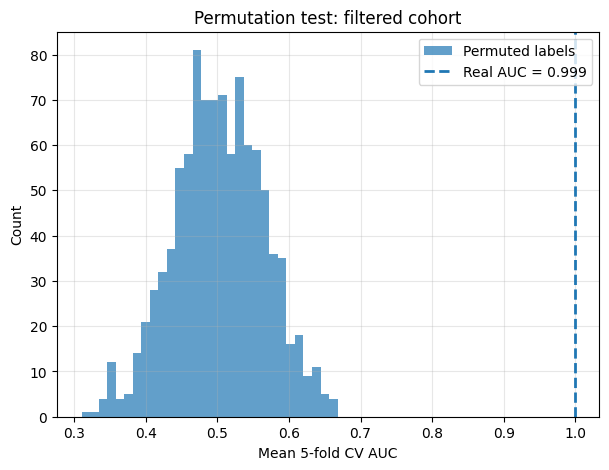

In [42]:
# =========================
# Permutation test on filtered cohort
# Hard FN + Hard FP removed
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# use X_filtered / y_filtered from previous cell
X_perm = X_filtered[LOCKED_PANEL].copy()
y_perm_true = y_filtered.copy()

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

real_auc_scores = cross_val_score(
    pipe,
    X_perm,
    y_perm_true,
    cv=cv,
    scoring="roc_auc"
)

real_auc = real_auc_scores.mean()

N_PERMUTATIONS = 1000
perm_aucs = []

rng = np.random.default_rng(42)

for i in range(N_PERMUTATIONS):
    y_shuffled = rng.permutation(y_perm_true.values)

    auc_i = cross_val_score(
        pipe,
        X_perm,
        y_shuffled,
        cv=cv,
        scoring="roc_auc"
    ).mean()

    perm_aucs.append(auc_i)

perm_aucs = np.array(perm_aucs)

p_value = (np.sum(perm_aucs >= real_auc) + 1) / (N_PERMUTATIONS + 1)

print("===== Permutation test: hard FN + hard FP removed =====")
print(f"Real 5-fold CV AUC: {real_auc:.3f}")
print(f"Permutation mean AUC: {perm_aucs.mean():.3f}")
print(f"Permutation std AUC : {perm_aucs.std():.3f}")
print(f"Permutation max AUC : {perm_aucs.max():.3f}")
print(f"Permutation p-value : {p_value:.5f}")

plt.figure(figsize=(7, 5))
plt.hist(perm_aucs, bins=30, alpha=0.7, label="Permuted labels")
plt.axvline(real_auc, linestyle="--", linewidth=2, label=f"Real AUC = {real_auc:.3f}")
plt.xlabel("Mean 5-fold CV AUC")
plt.ylabel("Count")
plt.title("Permutation test: filtered cohort")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Real 5-fold CV AUC: 0.849

===== PERMUTATION TEST =====
Real AUC           : 0.849
Permutation mean   : 0.498
Permutation std    : 0.057
Permutation max    : 0.657
Empirical p-value  : 0.00100


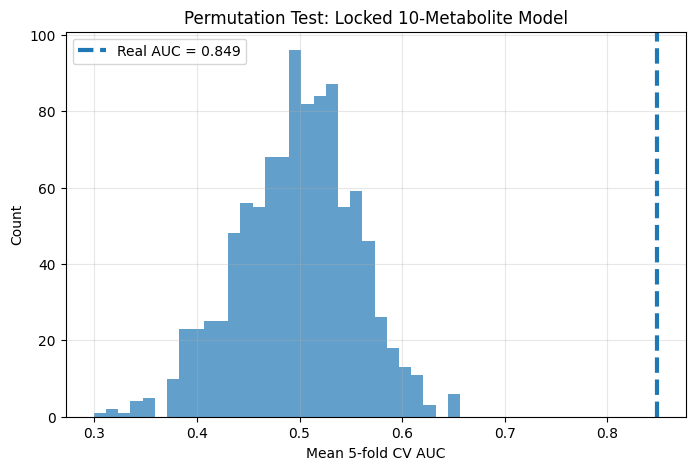

In [43]:
# =========================
# Permutation test
# ORIGINAL LOCKED 10 MODEL
# =========================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_perm = X_panel[LOCKED_PANEL].copy()
y_perm = y.copy()

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# -------------------------
# Real AUC
# -------------------------

real_scores = cross_val_score(
    pipe,
    X_perm,
    y_perm,
    cv=cv,
    scoring="roc_auc"
)

real_auc = real_scores.mean()

print(f"Real 5-fold CV AUC: {real_auc:.3f}")

# -------------------------
# Permutations
# -------------------------

N_PERMUTATIONS = 1000

rng = np.random.default_rng(42)

perm_aucs = []

for i in range(N_PERMUTATIONS):

    y_shuffled = rng.permutation(y_perm)

    auc = cross_val_score(
        pipe,
        X_perm,
        y_shuffled,
        cv=cv,
        scoring="roc_auc"
    ).mean()

    perm_aucs.append(auc)

perm_aucs = np.array(perm_aucs)

p_value = (
    np.sum(perm_aucs >= real_auc) + 1
) / (
    N_PERMUTATIONS + 1
)

# -------------------------
# Results
# -------------------------

print("\n===== PERMUTATION TEST =====")
print(f"Real AUC           : {real_auc:.3f}")
print(f"Permutation mean   : {perm_aucs.mean():.3f}")
print(f"Permutation std    : {perm_aucs.std():.3f}")
print(f"Permutation max    : {perm_aucs.max():.3f}")
print(f"Empirical p-value  : {p_value:.5f}")

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(8,5))

plt.hist(
    perm_aucs,
    bins=30,
    alpha=0.7
)

plt.axvline(
    real_auc,
    linestyle="--",
    linewidth=3,
    label=f"Real AUC = {real_auc:.3f}"
)

plt.xlabel("Mean 5-fold CV AUC")
plt.ylabel("Count")
plt.title("Permutation Test: Locked 10-Metabolite Model")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

===== Subtype counts =====


canonical_ME_CFS       121
canonical_control       58
ME_CFS_like_control     21
control_like_ME_CFS     14
Name: subtype, dtype: int64

PC1 variance: 0.203, PC2 variance: 0.164


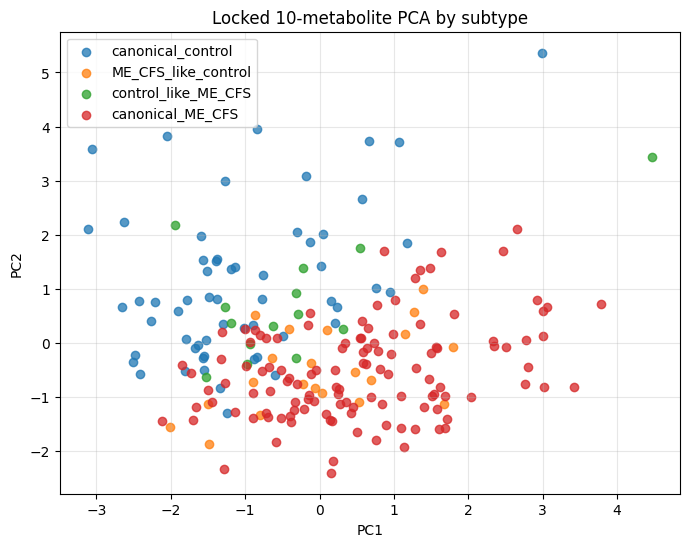


===== Locked metabolite means/medians by subtype =====


1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6)            \
                                                            mean    median   
subtype                                                                      
ME_CFS_like_control                                     1.459339  1.447557   
canonical_ME_CFS                                        1.482102  1.439010   
canonical_control                                       1.032113  1.035600   
control_like_ME_CFS                                     1.126382  1.111410   

                    N-acetylglutamate           N4-acetylcytidine            \
                                 mean    median              mean    median   
subtype                                                                       
ME_CFS_like_control          0.536779  0.504433          2.180367  2.086175   
canonical_ME_CFS             0.597434  0.569907          2.567274  2.296046   
canonical_control            0.438675  0.456570          1.562809  1.421810   
control_like_ME_CFS          0.558398  0.545302          2.214672  1.619260   

                    sphingomyelin (d18:1/24:1, d18:2/24:0)*            \
                                                       mean    median   
subtype                                                                 
ME_CFS_like_control                                1.225783  1.193343   
canonical_ME_CFS                                   1.279360  1.269256   
canonical_control                                  1.114624  1.117704   
control_like_ME_CFS                                1.118056  1.167990   

                    1-methylurate            \
                             mean    median   
subtype                                       
ME_CFS_like_control      0.506856  0.116026   
canonical_ME_CFS         0.594659  0.194419   
canonical_control        1.556749  1.249085   
control_like_ME_CFS      0.982297  0.317513   

                    N-palmitoyl-sphingosine (d18:1/16:0)            \
                                                    mean    median   
subtype                                                              
ME_CFS_like_control                             1.257880  1.205277   
canonical_ME_CFS                                1.355368  1.301122   
canonical_control                               1.087470  1.074263   
control_like_ME_CFS                             1.187495  1.188606   

                    3-(4-hydroxyphenyl)lactate            \
                                          mean    median   
subtype                                                    
ME_CFS_like_control                   0.806211  0.782641   
canonical_ME_CFS                      0.808934  0.738388   
canonical_control                     1.095909  1.067353   
control_like_ME_CFS                   1.021009  0.968676   

                    N-acetylglucosamine/N-acetylgalactosamine            \
                                                         mean    median   
subtype                                                                   
ME_CFS_like_control                                  0.736249  0.767447   
canonical_ME_CFS                                     0.847544  0.826731   
canonical_control                                    0.728314  0.691518   
control_like_ME_CFS                                  0.741761  0.720807   

                    vanillylmandelate (VMA)           4-vinylguaiacol sulfate  \
                                       mean    median                    mean   
subtype                                                                         
ME_CFS_like_control                1.261650  1.281828                0.070572   
canonical_ME_CFS                   1.136517  1.087349                0.132347   
canonical_control                  1.439320  1.452090                0.589223   
control_like_ME_CFS                1.554095  1.412128                0.253786   

                               
                       median  
subtype


===== canonical_ME_CFS vs canonical_control =====


,comparison,feature,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q
6,canonical_ME_CFS vs canonical_control,3-(4-hydroxyphenyl)lactate,121,58,0.808934,1.095909,0.738388,1.067353,-0.286975,-0.998667,2.101101e-10,2.101101e-09
0,canonical_ME_CFS vs canonical_control,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),121,58,1.482102,1.032113,1.439010,1.035600,0.449989,1.021185,8.941765e-09,4.470882e-08
4,canonical_ME_CFS vs canonical_control,1-methylurate,121,58,0.594659,1.556749,0.194419,1.249085,-0.962090,-0.748846,1.508734e-07,5.029112e-07
3,canonical_ME_CFS vs canonical_control,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",121,58,1.279360,1.114624,1.269256,1.117704,0.164736,0.910174,2.894855e-07,7.237138e-07
9,canonical_ME_CFS vs canonical_control,4-vinylguaiacol sulfate,121,58,0.132347,0.589223,0.070572,0.070572,-0.456876,-0.581600,3.907519e-07,7.815038e-07
5,canonical_ME_CFS vs canonical_control,N-palmitoyl-sphingosine (d18:1/16:0),121,58,1.355368,1.087470,1.301122,1.074263,0.267898,0.872154,1.058085e-06,1.763476e-06
2,canonical_ME_CFS vs canonical_control,N4-acetylcytidine,121,58,2.567274,1.562809,2.296046,1.421810,1.004465,0.812520,1.888308e-06,2.697583e-06
8,canonical_ME_CFS vs canonical_control,vanillylmandelate (VMA),121,58,1.136517,1.439320,1.087349,1.452090,-0.302803,-0.738904,3.003843e-05,3.754803e-05
1,canonical_ME_CFS vs canonical_control,N-acetylglutamate,121,58,0.597434,0.438675,0.569907,0.456570,0.158759,0.707103,1.347405e-04,1.497117e-04
7,canonical_ME_CFS vs canonical_control,N-acetylglucosamine/N-acetylgalactosamine,121,58,0.847544,0.728314,0.826731,0.691518,0.119230,0.471727,6.027216e-04,6.027216e-04



===== control_like_ME_CFS vs canonical_control =====


...

,comparison,feature,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q
8,control_like_ME_CFS vs canonical_ME_CFS,vanillylmandelate (VMA),14,121,1.554095,1.136517,1.412128,1.087349,0.417578,0.746360,0.004411,0.032914
3,control_like_ME_CFS vs canonical_ME_CFS,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",14,121,1.118056,1.279360,1.167990,1.269256,-0.161304,-0.836442,0.006583,0.032914
6,control_like_ME_CFS vs canonical_ME_CFS,3-(4-hydroxyphenyl)lactate,14,121,1.021009,0.808934,0.968676,0.738388,0.212075,0.660161,0.013993,0.046645
0,control_like_ME_CFS vs canonical_ME_CFS,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),14,121,1.126382,1.482102,1.111410,1.439010,-0.355719,-0.702845,0.021938,0.054845
9,control_like_ME_CFS vs canonical_ME_CFS,4-vinylguaiacol sulfate,14,121,0.253786,0.132347,0.070572,0.070572,0.121439,0.284101,0.057229,0.114457
2,control_like_ME_CFS vs canonical_ME_CFS,N4-acetylcytidine,14,121,2.214672,2.567274,1.619260,2.296046,-0.352602,-0.178535,0.089877,0.135383
7,control_like_ME_CFS vs canonical_ME_CFS,N-acetylglucosamine/N-acetylgalactosamine,14,121,0.741761,0.847544,0.720807,0.826731,-0.105783,-0.484622,0.094768,0.135383
5,control_like_ME_CFS vs canonical_ME_CFS,N-palmitoyl-sphingosine (d18:1/16:0),14,121,1.187495,1.355368,1.188606,1.301122,-0.167873,-0.563450,0.151972,0.189965
4,control_like_ME_CFS vs canonical_ME_CFS,1-methylurate,14,121,0.982297,0.594659,0.317513,0.194419,0.387639,0.272817,0.556007,0.617786
1,control_like_ME_CFS vs canonical_ME_CFS,N-acetylglutamate,14,121,0.558398,0.597434,0.545302,0.569907,-0.039036,-0.261435,0.626148,0.626148



===== ME_CFS_like_control vs canonical_control =====


,comparison,feature,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q
0,ME_CFS_like_control vs canonical_control,1-stearoyl-2-docosahexaenoyl-GPC (18:0/22:6),21,58,1.459339,1.032113,1.447557,1.035600,0.427225,1.237638,0.000017,0.000171
6,ME_CFS_like_control vs canonical_control,3-(4-hydroxyphenyl)lactate,21,58,0.806211,1.095909,0.782641,1.067353,-0.289698,-1.026275,0.000076,0.000381
4,ME_CFS_like_control vs canonical_control,1-methylurate,21,58,0.506856,1.556749,0.116026,1.249085,-1.049893,-0.837533,0.000218,0.000726
9,ME_CFS_like_control vs canonical_control,4-vinylguaiacol sulfate,21,58,0.070572,0.589223,0.070572,0.070572,-0.518651,-0.689940,0.001686,0.004215
5,ME_CFS_like_control vs canonical_control,N-palmitoyl-sphingosine (d18:1/16:0),21,58,1.257880,1.087470,1.205277,1.074263,0.170411,0.611177,0.030041,0.052066
3,ME_CFS_like_control vs canonical_control,"sphingomyelin (d18:1/24:1, d18:2/24:0)*",21,58,1.225783,1.114624,1.193343,1.117704,0.111159,0.619995,0.035469,0.052066
2,ME_CFS_like_control vs canonical_control,N4-acetylcytidine,21,58,2.180367,1.562809,2.086175,1.421810,0.617558,0.652872,0.036446,0.052066
8,ME_CFS_like_control vs canonical_control,vanillylmandelate (VMA),21,58,1.261650,1.439320,1.281828,1.452090,-0.177670,-0.377198,0.177550,0.221938
1,ME_CFS_like_control vs canonical_control,N-acetylglutamate,21,58,0.536779,0.438675,0.504433,0.456570,0.098104,0.441919,0.245546,0.272829
7,ME_CFS_like_control vs canonical_control,N-acetylglucosamine/N-acetylgalactosamine,21,58,0.736249,0.728314,0.767447,0.691518,0.007935,0.034342,0.339889,0.339889



===== Subtype score summary =====


,count,mean,median,std,min,max
subtype,,,,,,
canonical_control,58,0.196403,0.190217,0.153222,0.000884,0.479902
control_like_ME_CFS,14,0.375214,0.414735,0.125379,0.160067,0.600523
ME_CFS_like_control,21,0.748226,0.781459,0.121693,0.553362,0.964940
canonical_ME_CFS,121,0.841583,0.887725,0.139366,0.479950,0.999180


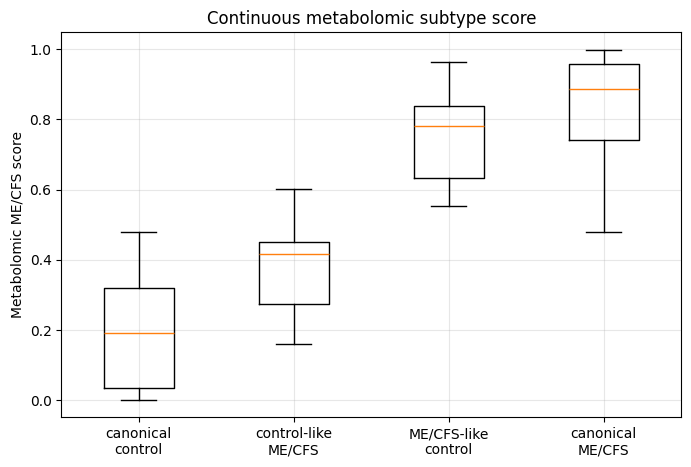


Saved:
..\..\output\locked_panel_biology/locked10_metabolomic_subtype_labels.csv
..\..\output\locked_panel_biology/locked10_subtype_pairwise_tests.csv


In [44]:
# =========================
# Identify metabolomic overlap subtypes
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import mannwhitneyu, chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests

# -------------------------
# 1. Define subtype groups
# -------------------------

HARD_FN_CUTOFF = 0.75
HARD_FP_CUTOFF = 0.75

hard_fn_ids = (
    patient_summary[
        (patient_summary["y_true"] == 1) &
        (patient_summary["FN_rate"] > HARD_FN_CUTOFF)
    ]["patient_id"].astype(str).tolist()
)

hard_fp_ids = (
    patient_summary[
        (patient_summary["y_true"] == 0) &
        (patient_summary["FP_rate"] > HARD_FP_CUTOFF)
    ]["patient_id"].astype(str).tolist()
)

X_sub = X_panel[LOCKED_PANEL].copy()
X_sub.index = X_sub.index.astype(str)

y_sub = y.copy()
y_sub.index = y_sub.index.astype(str)

subtype_df = pd.DataFrame({
    "patient_id": X_sub.index,
    "label": y_sub.loc[X_sub.index].values
})

subtype_df["subtype"] = np.where(
    subtype_df["label"] == 1,
    "canonical_ME_CFS",
    "canonical_control"
)

subtype_df.loc[subtype_df["patient_id"].isin(hard_fn_ids), "subtype"] = "control_like_ME_CFS"
subtype_df.loc[subtype_df["patient_id"].isin(hard_fp_ids), "subtype"] = "ME_CFS_like_control"

print("===== Subtype counts =====")
display(subtype_df["subtype"].value_counts())

# -------------------------
# 2. PCA visualization
# -------------------------

X_scaled = StandardScaler().fit_transform(X_sub)

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)

pca_df = subtype_df.copy()
pca_df["PC1"] = pcs[:, 0]
pca_df["PC2"] = pcs[:, 1]

print(
    f"PC1 variance: {pca.explained_variance_ratio_[0]:.3f}, "
    f"PC2 variance: {pca.explained_variance_ratio_[1]:.3f}"
)

plt.figure(figsize=(8, 6))

for subtype in [
    "canonical_control",
    "ME_CFS_like_control",
    "control_like_ME_CFS",
    "canonical_ME_CFS"
]:
    tmp = pca_df[pca_df["subtype"] == subtype]
    plt.scatter(tmp["PC1"], tmp["PC2"], label=subtype, alpha=0.75)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Locked 10-metabolite PCA by subtype")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 3. Group means / medians
# -------------------------

summary = (
    pd.concat([subtype_df.set_index("patient_id"), X_sub], axis=1)
    .groupby("subtype")[LOCKED_PANEL]
    .agg(["mean", "median"])
)

print("\n===== Locked metabolite means/medians by subtype =====")
display(summary)

# -------------------------
# 4. Pairwise subtype tests
# -------------------------

def pairwise_metabolite_test(group_a, group_b):
    rows = []

    ids_a = subtype_df[subtype_df["subtype"] == group_a]["patient_id"]
    ids_b = subtype_df[subtype_df["subtype"] == group_b]["patient_id"]

    for feature in LOCKED_PANEL:
        a = X_sub.loc[ids_a, feature].dropna()
        b = X_sub.loc[ids_b, feature].dropna()

        stat, p = mannwhitneyu(a, b, alternative="two-sided")

        pooled_sd = np.sqrt((a.std()**2 + b.std()**2) / 2)
        d = (a.mean() - b.mean()) / pooled_sd if pooled_sd != 0 else np.nan

        rows.append({
            "comparison": f"{group_a} vs {group_b}",
            "feature": feature,
            "n_A": len(a),
            "n_B": len(b),
            "mean_A": a.mean(),
            "mean_B": b.mean(),
            "median_A": a.median(),
            "median_B": b.median(),
            "delta_mean": a.mean() - b.mean(),
            "cohen_d": d,
            "p_value": p
        })

    out = pd.DataFrame(rows)
    out["fdr_q"] = multipletests(out["p_value"], method="fdr_bh")[1]
    return out.sort_values(["fdr_q", "p_value"])

comparisons = [
    ("canonical_ME_CFS", "canonical_control"),
    ("control_like_ME_CFS", "canonical_control"),
    ("ME_CFS_like_control", "canonical_ME_CFS"),
    ("control_like_ME_CFS", "canonical_ME_CFS"),
    ("ME_CFS_like_control", "canonical_control")
]

all_tests = []

for a, b in comparisons:
    temp = pairwise_metabolite_test(a, b)
    all_tests.append(temp)
    print(f"\n===== {a} vs {b} =====")
    display(temp)

all_subtype_tests = pd.concat(all_tests, ignore_index=True)

# -------------------------
# 5. Assign continuous subtype score
# -------------------------
# mean z-scored locked-panel probability-like direction
# uses final model coefficients if available, otherwise refits

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

score_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

score_pipe.fit(X_sub, y_sub)
subtype_df["metabolomic_ME_CFS_score"] = score_pipe.predict_proba(X_sub)[:, 1]

print("\n===== Subtype score summary =====")
display(
    subtype_df.groupby("subtype")["metabolomic_ME_CFS_score"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean")
)

plt.figure(figsize=(8, 5))
data = [
    subtype_df[subtype_df["subtype"] == s]["metabolomic_ME_CFS_score"]
    for s in [
        "canonical_control",
        "control_like_ME_CFS",
        "ME_CFS_like_control",
        "canonical_ME_CFS"
    ]
]

plt.boxplot(
    data,
    labels=[
        "canonical\ncontrol",
        "control-like\nME/CFS",
        "ME/CFS-like\ncontrol",
        "canonical\nME/CFS"
    ]
)

plt.ylabel("Metabolomic ME/CFS score")
plt.title("Continuous metabolomic subtype score")
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 6. Save subtype labels
# -------------------------

subtype_df.to_csv(f"{OUT_DIR}/locked10_metabolomic_subtype_labels.csv", index=False)
all_subtype_tests.to_csv(f"{OUT_DIR}/locked10_subtype_pairwise_tests.csv", index=False)

print("\nSaved:")
print(f"{OUT_DIR}/locked10_metabolomic_subtype_labels.csv")
print(f"{OUT_DIR}/locked10_subtype_pairwise_tests.csv")

In [45]:
# =========================
# Subtype association scan using metadata, Quest, immune, KEGG, species
# =========================

import numpy as np
import pandas as pd

from scipy.stats import mannwhitneyu, fisher_exact, chi2_contingency
from statsmodels.stats.multitest import multipletests

# -------------------------
# Helper functions
# -------------------------

def strip_tp(x):
    return str(x).replace("_tp1", "").replace("_tp2", "").replace("_tp3", "").replace("_t1", "").replace("_t2", "").replace("_t3", "")

def load_transposed_matrix(path, prefix):
    raw = pd.read_csv(path)
    feature_col = raw.columns[0]

    mat = raw.set_index(feature_col).T
    mat.index = mat.index.map(strip_tp).astype(str)

    mat = mat.apply(pd.to_numeric, errors="coerce")
    mat = mat.groupby(mat.index).mean()

    mat.columns = [f"{prefix}__{c}" for c in mat.columns]

    return mat

def prepare_metadata(path):
    meta = pd.read_csv(path)

    possible_id_cols = [
        "participant_id", "patient_id", "subject_id",
        "sample_id", "SampleID", "id", "ID"
    ]

    id_col = None
    for c in possible_id_cols:
        if c in meta.columns:
            id_col = c
            break

    if id_col is None:
        id_col = meta.columns[0]

    meta["patient_id"] = meta[id_col].map(strip_tp).astype(str)
    meta = meta.drop_duplicates("patient_id")
    meta = meta.set_index("patient_id")

    meta.columns = [f"metadata__{c}" for c in meta.columns]

    return meta

# -------------------------
# Start with subtype labels
# -------------------------

subtypes = subtype_df[["patient_id", "label", "subtype", "metabolomic_ME_CFS_score"]].copy()
subtypes["patient_id"] = subtypes["patient_id"].astype(str)
subtypes = subtypes.set_index("patient_id")

print("Subtype counts:")
display(subtypes["subtype"].value_counts())

# -------------------------
# Load all datasets
# -------------------------

meta = prepare_metadata(META_PATH)

quest = load_transposed_matrix(QUEST_PATH, "quest")
immune_pct = load_transposed_matrix(IMMUNE_PCT_PATH, "immune_pct")
immune_res = load_transposed_matrix(IMMUNE_RES_PATH, "immune_res")
kegg = load_transposed_matrix(KEGG_PATH, "kegg")
species = load_transposed_matrix(SPECIES_PATH, "species")

datasets = {
    "metadata": meta,
    "quest": quest,
    "immune_pct": immune_pct,
    "immune_res": immune_res,
    "kegg": kegg,
    "species": species
}

for name, d in datasets.items():
    print(f"{name}: {d.shape}")

# -------------------------
# Merge
# -------------------------

merged = subtypes.copy()

for name, d in datasets.items():
    before = merged.shape[1]
    merged = merged.join(d, how="left")
    print(f"{name}: added {merged.shape[1] - before} columns")

print("\nMerged shape:", merged.shape)

# -------------------------
# Comparisons of interest
# -------------------------

comparisons = [
    ("canonical_ME_CFS", "control_like_ME_CFS"),
    ("canonical_control", "ME_CFS_like_control"),
    ("canonical_ME_CFS", "canonical_control"),
    ("control_like_ME_CFS", "ME_CFS_like_control")
]

# -------------------------
# Numeric tests
# -------------------------

exclude_cols = {"label", "subtype"}

numeric_cols = [
    c for c in merged.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(merged[c])
]

numeric_rows = []

for group_a, group_b in comparisons:
    A = merged[merged["subtype"] == group_a]
    B = merged[merged["subtype"] == group_b]

    for col in numeric_cols:
        a = A[col].dropna()
        b = B[col].dropna()

        if len(a) < 5 or len(b) < 5:
            continue

        if a.nunique() < 2 or b.nunique() < 2:
            continue

        try:
            stat, p = mannwhitneyu(a, b, alternative="two-sided")
        except Exception:
            continue

        pooled_sd = np.sqrt((a.std() ** 2 + b.std() ** 2) / 2)
        d = (a.mean() - b.mean()) / pooled_sd if pooled_sd != 0 else np.nan

        numeric_rows.append({
            "comparison": f"{group_a} vs {group_b}",
            "variable": col,
            "n_A": len(a),
            "n_B": len(b),
            "mean_A": a.mean(),
            "mean_B": b.mean(),
            "median_A": a.median(),
            "median_B": b.median(),
            "delta_mean": a.mean() - b.mean(),
            "cohen_d": d,
            "p_value": p
        })

numeric_results = pd.DataFrame(numeric_rows)

if len(numeric_results) > 0:
    numeric_results["fdr_q"] = (
        numeric_results
        .groupby("comparison")["p_value"]
        .transform(lambda x: multipletests(x, method="fdr_bh")[1])
    )

    numeric_results["modality"] = numeric_results["variable"].str.split("__").str[0]

    numeric_results = numeric_results.sort_values(
        ["comparison", "fdr_q", "p_value"]
    )

print("\n===== Numeric subtype associations =====")
display(numeric_results.head(100))

# -------------------------
# Categorical metadata tests
# -------------------------

categorical_cols = [
    c for c in merged.columns
    if c.startswith("metadata__")
    and not pd.api.types.is_numeric_dtype(merged[c])
    and merged[c].nunique(dropna=True) >= 2
    and merged[c].nunique(dropna=True) <= 30
]

cat_rows = []

for group_a, group_b in comparisons:
    temp = merged[merged["subtype"].isin([group_a, group_b])].copy()

    for col in categorical_cols:
        tab = pd.crosstab(temp["subtype"], temp[col])

        if tab.shape[0] != 2 or tab.shape[1] < 2:
            continue

        try:
            if tab.shape == (2, 2):
                _, p = fisher_exact(tab)
            else:
                _, p, _, _ = chi2_contingency(tab)
        except Exception:
            continue

        cat_rows.append({
            "comparison": f"{group_a} vs {group_b}",
            "variable": col,
            "p_value": p,
            "table": tab.to_dict()
        })

categorical_results = pd.DataFrame(cat_rows)

if len(categorical_results) > 0:
    categorical_results["fdr_q"] = (
        categorical_results
        .groupby("comparison")["p_value"]
        .transform(lambda x: multipletests(x, method="fdr_bh")[1])
    )

    categorical_results = categorical_results.sort_values(
        ["comparison", "fdr_q", "p_value"]
    )

print("\n===== Categorical subtype associations =====")
display(categorical_results.head(50))

# -------------------------
# Top hits by comparison/modality
# -------------------------

print("\n===== Top numeric hits by comparison and modality =====")

for comp in numeric_results["comparison"].unique():
    print(f"\n--- {comp} ---")
    for mod in numeric_results["modality"].unique():
        temp = numeric_results[
            (numeric_results["comparison"] == comp) &
            (numeric_results["modality"] == mod)
        ].head(10)

        if len(temp) > 0:
            print(f"\n{mod}")
            display(temp)

# -------------------------
# Save outputs
# -------------------------

merged.to_csv(f"{OUT_DIR}/subtype_merged_all_modalities.csv")
numeric_results.to_csv(f"{OUT_DIR}/subtype_numeric_all_modalities.csv", index=False)
categorical_results.to_csv(f"{OUT_DIR}/subtype_categorical_metadata.csv", index=False)

print("\nSaved:")
print(f"{OUT_DIR}/subtype_merged_all_modalities.csv")
print(f"{OUT_DIR}/subtype_numeric_all_modalities.csv")
print(f"{OUT_DIR}/subtype_categorical_metadata.csv")

Subtype counts:


canonical_ME_CFS       121
canonical_control       58
ME_CFS_like_control     21
control_like_ME_CFS     14
Name: subtype, dtype: int64

metadata: (253, 22)
quest: (247, 37)
immune_pct: (242, 311)
immune_res: (242, 311)
kegg: (243, 4429)
species: (243, 118)
metadata: added 22 columns
quest: added 37 columns
immune_pct: added 311 columns
immune_res: added 311 columns
kegg: added 4429 columns
species: added 118 columns

Merged shape: (214, 5231)

===== Numeric subtype associations =====


,comparison,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q,modality
2,canonical_ME_CFS vs canonical_control,metabolomic_ME_CFS_score,121,58,0.841583,0.196403,0.887725,0.190217,0.645180,4.405225,2.968806e-27,2.968806e-27,metabolomic_ME_CFS_score
0,canonical_ME_CFS vs control_like_ME_CFS,metabolomic_ME_CFS_score,121,14,0.841583,0.375214,0.887725,0.414735,0.466369,3.518255,1.434475e-09,1.434475e-09,metabolomic_ME_CFS_score
1,canonical_control vs ME_CFS_like_control,metabolomic_ME_CFS_score,58,21,0.196403,0.748226,0.190217,0.781459,-0.551823,-3.988355,1.450393e-11,1.450393e-11,metabolomic_ME_CFS_score
3,control_like_ME_CFS vs ME_CFS_like_control,metabolomic_ME_CFS_score,14,21,0.375214,0.748226,0.414735,0.781459,-0.373011,-3.019126,1.892729e-06,1.892729e-06,metabolomic_ME_CFS_score



===== Categorical subtype associations =====


...


--- canonical_control vs ME_CFS_like_control ---

metabolomic_ME_CFS_score


,comparison,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q,modality
1,canonical_control vs ME_CFS_like_control,metabolomic_ME_CFS_score,58,21,0.196403,0.748226,0.190217,0.781459,-0.551823,-3.988355,1.450393e-11,1.450393e-11,metabolomic_ME_CFS_score



--- control_like_ME_CFS vs ME_CFS_like_control ---

metabolomic_ME_CFS_score


,comparison,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q,modality
3,control_like_ME_CFS vs ME_CFS_like_control,metabolomic_ME_CFS_score,14,21,0.375214,0.748226,0.414735,0.781459,-0.373011,-3.019126,0.000002,0.000002,metabolomic_ME_CFS_score



Saved:
..\..\output\locked_panel_biology/subtype_merged_all_modalities.csv
..\..\output\locked_panel_biology/subtype_numeric_all_modalities.csv
..\..\output\locked_panel_biology/subtype_categorical_metadata.csv


In [46]:
for name, d in datasets.items():
    overlap = len(set(subtypes.index) & set(d.index))
    print(name, overlap)
    

metadata 0
quest 0
immune_pct 0
immune_res 0
kegg 0
species 0


In [47]:
print("Subtype IDs")
print(list(subtype_df["patient_id"].astype(str).head(10)))

print("\nQuest IDs")
print(list(quest.index.astype(str)[:10]))

print("\nImmune IDs")
print(list(immune_pct.index.astype(str)[:10]))

print("\nKEGG IDs")
print(list(kegg.index.astype(str)[:10]))

print("\nSpecies IDs")
print(list(species.index.astype(str)[:10]))

Subtype IDs
['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Quest IDs
['SAM000200', 'SAM000201', 'SAM000201_tp4', 'SAM000202', 'SAM000202_tp4', 'SAM000203', 'SAM000204', 'SAM000205', 'SAM000206', 'SAM000207']

Immune IDs
['SAM000201', 'SAM000201_tp4', 'SAM000202', 'SAM000203', 'SAM000204', 'SAM000205', 'SAM000206', 'SAM000207', 'SAM000208', 'SAM000209']

KEGG IDs
['SAM000201', 'SAM000201_tp4', 'SAM000202', 'SAM000202_tp4', 'SAM000203', 'SAM000204', 'SAM000205', 'SAM000206', 'SAM000208', 'SAM000209']

Species IDs
['SAM000201', 'SAM000201_tp4', 'SAM000202', 'SAM000202_tp4', 'SAM000203', 'SAM000204', 'SAM000205', 'SAM000206', 'SAM000208', 'SAM000209']


In [48]:
# =========================
# TRUE FIX:
# Convert patient_summary numeric IDs -> real SAM IDs using df
# Then merge all modalities + test subtype associations
# =========================

import os, re
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, fisher_exact, chi2_contingency
from statsmodels.stats.multitest import multipletests

def strip_tp(x):
    x = str(x)
    x = re.sub(r"_tp\d+$", "", x)
    x = re.sub(r"_t\d+$", "", x)
    return x

def load_transposed_matrix(path, prefix):
    raw = pd.read_csv(path)
    feature_col = raw.columns[0]
    mat = raw.set_index(feature_col).T
    mat.index = mat.index.map(strip_tp).astype(str)
    mat = mat.apply(pd.to_numeric, errors="coerce")
    mat = mat.groupby(mat.index).mean()
    mat.columns = [f"{prefix}__{c}" for c in mat.columns]
    return mat

def prepare_metadata(path):
    meta = pd.read_csv(path)

    possible_id_cols = [
        "participant_id", "patient_id", "subject_id",
        "sample_id", "SampleID", "id", "ID"
    ]

    id_col = None
    for c in possible_id_cols:
        if c in meta.columns:
            id_col = c
            break

    if id_col is None:
        id_col = meta.columns[0]

    meta["patient_id"] = meta[id_col].map(strip_tp).astype(str)
    meta = meta.drop_duplicates("patient_id")
    meta = meta.set_index("patient_id")
    meta.columns = [f"metadata__{c}" for c in meta.columns]
    return meta

# -------------------------
# 1. Build row-number -> real patient ID map from df
# -------------------------

print("df columns:")
print(df.columns.tolist())

if "participant_id" in df.columns:
    id_source = df["participant_id"].astype(str).map(strip_tp).reset_index(drop=True)
elif "patient_id" in df.columns:
    id_source = df["patient_id"].astype(str).map(strip_tp).reset_index(drop=True)
elif "sample_id" in df.columns:
    id_source = df["sample_id"].astype(str).map(strip_tp).reset_index(drop=True)
else:
    raise ValueError("Could not find participant_id / patient_id / sample_id column in df.")

# patient_summary patient_id is currently 0,1,2...
subtype_df_fixed = patient_summary.copy()
subtype_df_fixed["row_id"] = subtype_df_fixed["patient_id"].astype(int)
subtype_df_fixed["patient_id"] = subtype_df_fixed["row_id"].map(id_source)

print("\nExample real patient IDs:")
print(subtype_df_fixed["patient_id"].head(10).tolist())

# -------------------------
# 2. Assign subtype labels
# -------------------------

HARD_FN_CUTOFF = 0.75
HARD_FP_CUTOFF = 0.75

subtype_df_fixed["subtype"] = "unknown"

subtype_df_fixed.loc[
    (subtype_df_fixed["y_true"] == 1) &
    (subtype_df_fixed["FN_rate"] <= HARD_FN_CUTOFF),
    "subtype"
] = "canonical_ME_CFS"

subtype_df_fixed.loc[
    (subtype_df_fixed["y_true"] == 1) &
    (subtype_df_fixed["FN_rate"] > HARD_FN_CUTOFF),
    "subtype"
] = "control_like_ME_CFS"

subtype_df_fixed.loc[
    (subtype_df_fixed["y_true"] == 0) &
    (subtype_df_fixed["FP_rate"] <= HARD_FP_CUTOFF),
    "subtype"
] = "canonical_control"

subtype_df_fixed.loc[
    (subtype_df_fixed["y_true"] == 0) &
    (subtype_df_fixed["FP_rate"] > HARD_FP_CUTOFF),
    "subtype"
] = "ME_CFS_like_control"

print("\n===== Subtype counts =====")
display(subtype_df_fixed["subtype"].value_counts())

# -------------------------
# 3. Load modalities
# -------------------------

meta = prepare_metadata(META_PATH)
quest = load_transposed_matrix(QUEST_PATH, "quest")
immune_pct = load_transposed_matrix(IMMUNE_PCT_PATH, "immune_pct")
immune_res = load_transposed_matrix(IMMUNE_RES_PATH, "immune_res")
kegg = load_transposed_matrix(KEGG_PATH, "kegg")
species = load_transposed_matrix(SPECIES_PATH, "species")

datasets = {
    "metadata": meta,
    "quest": quest,
    "immune_pct": immune_pct,
    "immune_res": immune_res,
    "kegg": kegg,
    "species": species
}

# -------------------------
# 4. Merge
# -------------------------

subtypes = subtype_df_fixed[
    [
        "patient_id", "y_true", "subtype",
        "mean_prob", "median_prob",
        "FP_rate", "FN_rate", "correct_rate", "error_rate"
    ]
].copy()

subtypes = subtypes.set_index("patient_id")
subtypes.index = subtypes.index.astype(str)

print("\n===== ID overlap check =====")
for name, d in datasets.items():
    overlap = len(set(subtypes.index) & set(d.index))
    print(f"{name}: {overlap}")

merged = subtypes.copy()

for name, d in datasets.items():
    merged = merged.join(d, how="left")

print("\nMerged shape:", merged.shape)

print("\n===== Non-null participants by modality =====")
for name in datasets:
    cols = [c for c in merged.columns if c.startswith(f"{name}__")]
    print(name, merged[cols].notna().any(axis=1).sum())

# -------------------------
# 5. Numeric association tests
# -------------------------

comparisons = [
    ("canonical_ME_CFS", "control_like_ME_CFS"),
    ("canonical_control", "ME_CFS_like_control"),
    ("canonical_ME_CFS", "canonical_control"),
    ("control_like_ME_CFS", "ME_CFS_like_control"),
]

exclude_cols = {"y_true", "subtype"}

numeric_cols = [
    c for c in merged.columns
    if c not in exclude_cols and pd.api.types.is_numeric_dtype(merged[c])
]

numeric_rows = []

for group_a, group_b in comparisons:
    A = merged[merged["subtype"] == group_a]
    B = merged[merged["subtype"] == group_b]

    for col in numeric_cols:
        a = A[col].dropna()
        b = B[col].dropna()

        if len(a) < 5 or len(b) < 5:
            continue
        if a.nunique() < 2 or b.nunique() < 2:
            continue

        try:
            _, p = mannwhitneyu(a, b, alternative="two-sided")
        except Exception:
            continue

        pooled_sd = np.sqrt((a.std()**2 + b.std()**2) / 2)
        d = (a.mean() - b.mean()) / pooled_sd if pooled_sd != 0 else np.nan

        modality = col.split("__")[0] if "__" in col else "model_error_metrics"

        numeric_rows.append({
            "comparison": f"{group_a} vs {group_b}",
            "modality": modality,
            "variable": col,
            "n_A": len(a),
            "n_B": len(b),
            "mean_A": a.mean(),
            "mean_B": b.mean(),
            "median_A": a.median(),
            "median_B": b.median(),
            "delta_mean": a.mean() - b.mean(),
            "cohen_d": d,
            "p_value": p
        })

numeric_results = pd.DataFrame(numeric_rows)

if len(numeric_results) > 0:
    numeric_results["fdr_q"] = (
        numeric_results
        .groupby("comparison")["p_value"]
        .transform(lambda x: multipletests(x, method="fdr_bh")[1])
    )

    numeric_results = numeric_results.sort_values(
        ["comparison", "fdr_q", "p_value"]
    )

print("\n===== Numeric subtype associations: top 100 =====")
display(numeric_results.head(100))

# -------------------------
# 6. Categorical metadata tests
# -------------------------

categorical_cols = [
    c for c in merged.columns
    if c.startswith("metadata__")
    and not pd.api.types.is_numeric_dtype(merged[c])
    and merged[c].nunique(dropna=True) >= 2
    and merged[c].nunique(dropna=True) <= 30
]

cat_rows = []

for group_a, group_b in comparisons:
    temp = merged[merged["subtype"].isin([group_a, group_b])].copy()

    for col in categorical_cols:
        tab = pd.crosstab(temp["subtype"], temp[col])

        if tab.shape[0] != 2 or tab.shape[1] < 2:
            continue

        try:
            if tab.shape == (2, 2):
                _, p = fisher_exact(tab)
            else:
                _, p, _, _ = chi2_contingency(tab)
        except Exception:
            continue

        cat_rows.append({
            "comparison": f"{group_a} vs {group_b}",
            "variable": col,
            "p_value": p,
            "table": tab.to_dict()
        })

categorical_results = pd.DataFrame(cat_rows)

if len(categorical_results) > 0:
    categorical_results["fdr_q"] = (
        categorical_results
        .groupby("comparison")["p_value"]
        .transform(lambda x: multipletests(x, method="fdr_bh")[1])
    )

    categorical_results = categorical_results.sort_values(
        ["comparison", "fdr_q", "p_value"]
    )

print("\n===== Categorical metadata associations =====")
display(categorical_results.head(50))

# -------------------------
# 7. Top hits by comparison/modality
# -------------------------

print("\n===== Top numeric hits by comparison and modality =====")

for comp in numeric_results["comparison"].unique():
    print(f"\n\n### {comp} ###")

    for mod in sorted(numeric_results["modality"].unique()):
        temp = numeric_results[
            (numeric_results["comparison"] == comp) &
            (numeric_results["modality"] == mod)
        ].sort_values(["fdr_q", "p_value"]).head(10)

        if len(temp) > 0:
            print(f"\n--- {mod} ---")
            display(temp)

# -------------------------
# 8. Save
# -------------------------

os.makedirs(OUT_DIR, exist_ok=True)

merged.to_csv(f"{OUT_DIR}/subtype_merged_all_modalities_TRUE_FIXED.csv")
numeric_results.to_csv(f"{OUT_DIR}/subtype_numeric_all_modalities_TRUE_FIXED.csv", index=False)
categorical_results.to_csv(f"{OUT_DIR}/subtype_categorical_metadata_TRUE_FIXED.csv", index=False)
subtype_df_fixed.to_csv(f"{OUT_DIR}/subtype_labels_TRUE_FIXED.csv", index=False)

print("\nSaved TRUE fixed outputs.")

df columns:
['sample_id', 'S-1-pyrroline-5-carboxylate', '1-methylnicotinamide', 'alpha-ketoglutarate', '3-hydroxyisobutyrate', '3-hydroxy-3-methylglutarate', 'cholate', '4-hydroxyphenylacetate', '5,6-dihydrothymine', '9,10-DiHOME', 'linoleate (18:2n6)', 'laurate (12:0)', 'N6,N6,N6-trimethyllysine', 'N-acetylputrescine', 'N-formylmethionine', 'S-adenosylhomocysteine (SAH)', "adenosine 5'-monophosphate (AMP)", '5-methylthioadenosine (MTA)', 'arachidonate (20:4n6)', 'arginine', '2-hydroxyphenylacetate', '3-(4-hydroxyphenyl)lactate', 'beta-alanine', '3-hydroxybutyrate (BHBA)', 'choline phosphate', 'cysteinylglycine', 'cystine', 'sphingosine', 'deoxycholate', 'cystathionine', 'sphinganine', 'fumarate', 'gamma-glutamylglutamate', 'glutarate (C5-DC)', 'glycocholate', 'guanidinoacetate', 'hypotaurine', 'myo-inositol', 'citrulline', 'malate', 'methylmalonate (MMA)', 'palmitate (16:0)', 'nicotinamide', 'stearate (18:0)', 'ornithine', 'palmitoleate (16:1n7)', 'phytanate', 'pyridoxal', 'retinol (

canonical_ME_CFS       121
canonical_control       58
ME_CFS_like_control     21
control_like_ME_CFS     14
Name: subtype, dtype: int64


===== ID overlap check =====
metadata: 214
quest: 212
immune_pct: 210
immune_res: 210
kegg: 210
species: 210

Merged shape: (214, 5236)

===== Non-null participants by modality =====
metadata 214
quest 212
immune_pct 210
immune_res 210
kegg 210
species 210

===== Numeric subtype associations: top 100 =====


,comparison,modality,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q
10423,canonical_ME_CFS vs canonical_control,model_error_metrics,mean_prob,121,58,0.829691,0.215304,0.878004,0.213513,0.614387,3.863596,4.015889e-27,1.083253e-23
10424,canonical_ME_CFS vs canonical_control,model_error_metrics,median_prob,121,58,0.831056,0.214506,0.881687,0.213980,0.616550,3.865631,4.152781e-27,1.083253e-23
11281,canonical_ME_CFS vs canonical_control,kegg,kegg__K00385,118,57,24.298928,9.592162,14.775487,6.214564,14.706766,0.603160,4.210104e-07,7.321371e-04
12004,canonical_ME_CFS vs canonical_control,kegg,kegg__K01972,118,57,2319.365054,2102.869712,2315.744698,2081.022486,216.495343,0.670588,1.720371e-06,1.618746e-03
10438,canonical_ME_CFS vs canonical_control,quest,quest__Non HDL Cholesterol,120,57,0.533708,0.429473,0.516037,0.400535,0.104235,0.770106,2.429970e-06,1.618746e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14620,canonical_ME_CFS vs canonical_control,kegg,kegg__K13012,118,57,75.029190,116.257633,69.281089,111.228784,-41.228442,-0.679049,8.146669e-05,4.422561e-03
11734,canonical_ME_CFS vs canonical_control,kegg,kegg__K01524,118,57,634.717542,493.047728,580.118434,449.845464,141.669815,0.552092,8.365647e-05,4.422561e-03
12363,canonical_ME_CFS vs canonical_control,kegg,kegg__K02619,118,57,279.224006,221.258720,268.576810,200.272888,57.965286,0.653917,8.477210e-05,4.422561e-03
13563,canonical_ME_CFS vs canonical_control,kegg,kegg__K07078,118,57,408.924531,332.743294,421.871194,354.225096,76.181238,0.587960,8.477210e-05,4.422561e-03



===== Categorical metadata associations =====


...


--- quest ---


,comparison,modality,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q
15686,control_like_ME_CFS vs ME_CFS_like_control,quest,quest__Vitamin B12,14,21,0.486518,0.315338,0.405202,0.285393,0.171180,1.009732,0.003990,0.772799
15669,control_like_ME_CFS vs ME_CFS_like_control,quest,quest__Sed Rate,14,21,0.097031,0.220975,0.046334,0.217274,-0.123944,-1.011529,0.008578,0.772799
15672,control_like_ME_CFS vs ME_CFS_like_control,quest,quest__Hemoglobin,14,21,0.790806,0.702897,0.765173,0.703757,0.087909,0.989357,0.008606,0.772799
15657,control_like_ME_CFS vs ME_CFS_like_control,quest,quest__Creatinine,14,21,0.437720,0.280203,0.432099,0.277778,0.157518,0.890972,0.016046,0.772799
15673,control_like_ME_CFS vs ME_CFS_like_control,quest,quest__Hemocrit,14,21,0.756803,0.681519,0.747619,0.685714,0.075283,0.943906,0.016053,0.772799
15666,control_like_ME_CFS vs ME_CFS_like_control,quest,"quest__Bilirubin, Total",14,21,0.018657,0.012971,0.019279,0.009328,0.005686,0.698522,0.017327,0.772799
15656,control_like_ME_CFS vs ME_CFS_like_control,quest,quest__Urea Nitrogen (BUN),14,21,0.346429,0.254762,0.333333,0.266667,0.091667,0.785602,0.038173,0.772799
15658,control_like_ME_CFS vs ME_CFS_like_control,quest,quest__eGFR non-African American,14,21,0.650251,0.755460,0.647243,0.804511,-0.105209,-0.710008,0.052836,0.786140
15676,control_like_ME_CFS vs ME_CFS_like_control,quest,quest__Platelet Count,14,21,0.549344,0.638204,0.540435,0.643708,-0.088860,-0.686931,0.054914,0.788290
15659,control_like_ME_CFS vs ME_CFS_like_control,quest,quest__eGFR African American,14,21,0.650512,0.756803,0.648268,0.805195,-0.106291,-0.718553,0.057060,0.788290



--- species ---


,comparison,modality,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q
20760,control_like_ME_CFS vs ME_CFS_like_control,species,species__Alistipes_shahii,14,21,0.003253,0.008416,0.002444,0.007242,-0.005163,-1.063722,0.006398,0.772799
20819,control_like_ME_CFS vs ME_CFS_like_control,species,species__Clostridiales_bacterium,14,21,0.003497,0.001470,0.002286,0.000491,0.002027,0.493097,0.020992,0.772799
20755,control_like_ME_CFS vs ME_CFS_like_control,species,species__Bacteroides_xylanisolvens,14,21,0.009073,0.008171,0.000000,0.002429,0.000903,0.043770,0.023576,0.772799
20806,control_like_ME_CFS vs ME_CFS_like_control,species,species__Flavonifractor_plautii,14,21,0.003894,0.002080,0.001244,0.000472,0.001813,0.328844,0.026815,0.772799
20803,control_like_ME_CFS vs ME_CFS_like_control,species,species__Blautia_massiliensis,14,21,0.003013,0.001307,0.001918,0.000663,0.001706,0.691811,0.028610,0.772799
20840,control_like_ME_CFS vs ME_CFS_like_control,species,species__Ruminococcus_gnavus,14,21,0.001660,0.000248,0.000172,0.000000,0.001411,0.481672,0.040055,0.772799
20770,control_like_ME_CFS vs ME_CFS_like_control,species,species__Dysosmobacter_welbionis,14,21,0.005262,0.003157,0.004953,0.001934,0.002105,0.544358,0.057112,0.788290
20756,control_like_ME_CFS vs ME_CFS_like_control,species,species__Bacteroides_fragilis,14,21,0.032680,0.003917,0.002833,0.000000,0.028763,0.415022,0.063101,0.805988
20754,control_like_ME_CFS vs ME_CFS_like_control,species,species__Phocaeicola_massiliensis,14,21,0.003724,0.016169,0.000000,0.000000,-0.012445,-0.589236,0.075236,0.805988
20792,control_like_ME_CFS vs ME_CFS_like_control,species,species__Roseburia_inulinivorans,14,21,0.002072,0.004057,0.000402,0.002774,-0.001985,-0.465442,0.076686,0.805988



Saved TRUE fixed outputs.


In [49]:
# =========================
# Focus only on overlap-subtype biology
# =========================

overlap_comps = [
    "canonical_ME_CFS vs control_like_ME_CFS",
    "canonical_control vs ME_CFS_like_control"
]

overlap_hits = numeric_results[
    numeric_results["comparison"].isin(overlap_comps)
].copy()

# remove model-error metrics because those define the subtype
overlap_hits = overlap_hits[
    overlap_hits["modality"] != "model_error_metrics"
]

overlap_hits = overlap_hits.sort_values(["comparison", "fdr_q", "p_value"])

print("===== Top overlap-subtype numeric hits =====")
display(overlap_hits.head(100))

print("\n===== Significant overlap hits FDR < 0.05 =====")
display(overlap_hits[overlap_hits["fdr_q"] < 0.05])

print("\n===== Top hits by comparison and modality =====")

for comp in overlap_comps:
    print(f"\n\n### {comp} ###")
    for mod in sorted(overlap_hits["modality"].unique()):
        temp = overlap_hits[
            (overlap_hits["comparison"] == comp) &
            (overlap_hits["modality"] == mod)
        ].sort_values(["fdr_q", "p_value"]).head(10)

        if len(temp) > 0:
            print(f"\n--- {mod} ---")
            display(temp)

===== Top overlap-subtype numeric hits =====


,comparison,modality,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q
4378,canonical_ME_CFS vs control_like_ME_CFS,kegg,kegg__K15342,118,14,533.964390,316.782448,520.860196,311.627642,217.181942,1.121972,0.000406,0.352359
980,canonical_ME_CFS vs control_like_ME_CFS,kegg,kegg__K00784,118,14,1072.700024,1177.249024,1083.844568,1205.057725,-104.549000,-0.833963,0.002033,1.000000
4593,canonical_ME_CFS vs control_like_ME_CFS,kegg,kegg__K17723,118,14,125.137867,58.100317,110.508428,27.495086,67.037549,0.756185,0.002663,1.000000
34,canonical_ME_CFS vs control_like_ME_CFS,quest,quest__Hemoglobin,120,14,0.706220,0.790806,0.689306,0.765173,-0.084587,-0.855160,0.003257,1.000000
35,canonical_ME_CFS vs control_like_ME_CFS,quest,quest__Hemocrit,120,14,0.685331,0.756803,0.678571,0.747619,-0.071472,-0.786560,0.006033,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,canonical_ME_CFS vs control_like_ME_CFS,immune_pct,immune_pct__% CD8+ MAIT INFg+ TNFa+ d6,119,14,89.535854,82.746429,92.850000,87.383333,6.789426,0.558685,0.053823,1.000000
1911,canonical_ME_CFS vs control_like_ME_CFS,kegg,kegg__K02554,118,14,9.091442,4.988830,2.916243,1.241116,4.102612,0.264903,0.054778,1.000000
4570,canonical_ME_CFS vs control_like_ME_CFS,kegg,kegg__K17234,118,14,41.603799,59.094531,36.267256,49.063658,-17.490732,-0.488256,0.056073,1.000000
3657,canonical_ME_CFS vs control_like_ME_CFS,kegg,kegg__K09459,118,14,73.498897,37.704205,43.927569,23.502491,35.794692,0.586952,0.056078,1.000000



===== Significant overlap hits FDR < 0.05 =====


,comparison,modality,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q



===== Top hits by comparison and modality =====


### canonical_ME_CFS vs control_like_ME_CFS ###

--- immune_pct ---


...

,comparison,modality,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q
5219,canonical_control vs ME_CFS_like_control,metadata,metadata__diet_grains,58,21,2.931034,3.571429,3.00000,4.000000,-0.640394,-0.757479,0.002477,1.0
5216,canonical_control vs ME_CFS_like_control,metadata,metadata__diet_meat,58,21,2.379310,2.047619,3.00000,2.000000,0.331691,0.426750,0.078109,1.0
5220,canonical_control vs ME_CFS_like_control,metadata,metadata__diet_fruit,58,21,3.068966,3.238095,3.00000,3.000000,-0.169130,-0.178382,0.420712,1.0
5214,canonical_control vs ME_CFS_like_control,metadata,metadata__age,58,21,40.586207,39.523810,36.00000,34.000000,1.062397,0.075630,0.594033,1.0
5217,canonical_control vs ME_CFS_like_control,metadata,metadata__diet_sugar,58,21,2.982759,3.047619,3.00000,3.000000,-0.064860,-0.084044,0.665850,1.0
5215,canonical_control vs ME_CFS_like_control,metadata,metadata__bmi,45,14,25.777061,25.864631,23.64736,24.840578,-0.087570,-0.016035,0.775581,1.0
5218,canonical_control vs ME_CFS_like_control,metadata,metadata__diet_veg,58,21,3.465517,3.333333,4.00000,4.000000,0.132184,0.158158,0.890252,1.0



--- quest ---


,comparison,modality,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q
5239,canonical_control vs ME_CFS_like_control,quest,quest__Sed Rate,57,21,0.109613,0.220975,0.064327,0.217274,-0.111362,-0.850963,0.000509,0.331449
5225,canonical_control vs ME_CFS_like_control,quest,quest__Non HDL Cholesterol,57,21,0.429473,0.539901,0.400535,0.526537,-0.110428,-0.786973,0.002102,1.000000
5223,canonical_control vs ME_CFS_like_control,quest,quest__LDL-Cholesterol,57,21,0.414576,0.521036,0.397401,0.489247,-0.106460,-0.760938,0.003524,1.000000
5236,canonical_control vs ME_CFS_like_control,quest,"quest__Bilirubin, Total",57,21,0.018755,0.012971,0.014925,0.009328,0.005784,0.474782,0.005511,1.000000
5221,canonical_control vs ME_CFS_like_control,quest,"quest__Cholesterol, Total",57,21,0.335650,0.458783,0.304245,0.391509,-0.123132,-0.717586,0.007461,1.000000
5246,canonical_control vs ME_CFS_like_control,quest,quest__Platelet Count,57,21,0.555112,0.638204,0.540038,0.643708,-0.083092,-0.642654,0.010213,1.000000
5227,canonical_control vs ME_CFS_like_control,quest,quest__Creatinine,57,21,0.360840,0.280203,0.330247,0.277778,0.080638,0.635849,0.018255,1.000000
5224,canonical_control vs ME_CFS_like_control,quest,quest__Chol/HDLC Ratio,57,21,0.003541,0.003723,0.002151,0.002978,-0.000181,-0.036821,0.032744,1.000000
5237,canonical_control vs ME_CFS_like_control,quest,quest__Alkaline Phosphatase,57,21,0.259714,0.323964,0.251701,0.304029,-0.064250,-0.577964,0.034662,1.000000
5257,canonical_control vs ME_CFS_like_control,quest,quest__C-Reactive Protein,57,21,0.003337,0.006927,0.001714,0.002892,-0.003589,-0.516656,0.057530,1.000000



--- species ---


,comparison,modality,variable,n_A,n_B,mean_A,mean_B,median_A,median_B,delta_mean,cohen_d,p_value,fdr_q
10368,canonical_control vs ME_CFS_like_control,species,species__Ruminococcaceae_unclassified_SGB15265,57,21,0.003191,0.000865,0.001092,0.000000,0.002326,0.587373,0.017676,1.0
10335,canonical_control vs ME_CFS_like_control,species,species__Phocaeicola_plebeius,57,21,0.006701,0.022094,0.000000,0.000000,-0.015393,-0.355226,0.025504,1.0
10408,canonical_control vs ME_CFS_like_control,species,species__Ruminococcaceae_unclassified_SGB15260,57,21,0.000879,0.002566,0.000000,0.000000,-0.001687,-0.406965,0.027205,1.0
10363,canonical_control vs ME_CFS_like_control,species,species__Coprococcus_eutactus,57,21,0.007660,0.003660,0.001225,0.000000,0.004000,0.339645,0.061963,1.0
10394,canonical_control vs ME_CFS_like_control,species,species__GGB3746_SGB5089,57,21,0.001808,0.001017,0.000695,0.000000,0.000791,0.353249,0.067336,1.0
10340,canonical_control vs ME_CFS_like_control,species,species__Gemmiger_formicilis,57,21,0.003380,0.007419,0.001256,0.003165,-0.004040,-0.543782,0.068558,1.0
10331,canonical_control vs ME_CFS_like_control,species,species__Alistipes_shahii,57,21,0.006553,0.008416,0.004998,0.007242,-0.001863,-0.277827,0.094046,1.0
10359,canonical_control vs ME_CFS_like_control,species,species__GGB6613_SGB9347,57,21,0.002685,0.000152,0.000000,0.000000,0.002533,0.558187,0.103226,1.0
10420,canonical_control vs ME_CFS_like_control,species,species__Sutterella_SGB9281,57,21,0.000074,0.002383,0.000000,0.000000,-0.002308,-0.332941,0.112050,1.0
10388,canonical_control vs ME_CFS_like_control,species,species__Lacrimispora_amygdalina,57,21,0.001878,0.002526,0.001397,0.002458,-0.000648,-0.339158,0.115415,1.0


In [50]:
# =========================
# 500-split robustness analysis
# Locked 10 metabolite panel
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix
)

N_SPLITS = 1000

results = []

for seed in range(N_SPLITS):

    X_train, X_test, y_train, y_test = train_test_split(
        X_panel[LOCKED_PANEL],
        y,
        test_size=0.20,
        stratify=y,
        random_state=seed
    )

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            max_iter=5000,
            random_state=seed
        ))
    ])

    pipe.fit(X_train, y_train)

    probs = pipe.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.50).astype(int)

    auc = roc_auc_score(y_test, probs)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        preds
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    results.append({
        "seed": seed,
        "auc": auc,
        "accuracy": accuracy_score(y_test, preds),
        "balanced_accuracy": balanced_accuracy_score(y_test, preds),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

results_df = pd.DataFrame(results)

print("===== 500-split summary =====")
display(
    results_df[
        [
            "auc",
            "accuracy",
            "balanced_accuracy",
            "sensitivity",
            "specificity",
            "TP",
            "TN",
            "FP",
            "FN"
        ]
    ].agg(
        ["mean", "median", "std",
         lambda x: x.quantile(0.05),
         lambda x: x.quantile(0.95)]
    )
)

print("\n===== Average confusion matrix counts =====")
print(f"TP: {results_df['TP'].mean():.2f}")
print(f"TN: {results_df['TN'].mean():.2f}")
print(f"FP: {results_df['FP'].mean():.2f}")
print(f"FN: {results_df['FN'].mean():.2f}")

print("\n===== Worst FN splits =====")
display(
    results_df.sort_values(
        ["FN", "FP"],
        ascending=False
    ).head(10)
)

print("\n===== Worst FP splits =====")
display(
    results_df.sort_values(
        ["FP", "FN"],
        ascending=False
    ).head(10)
)


===== 500-split summary =====


,auc,accuracy,balanced_accuracy,sensitivity,specificity,TP,TN,FP,FN
mean,0.860706,0.807209,0.785103,0.871519,0.698688,23.53100,11.179000,4.821000,3.46900
median,0.863426,0.813953,0.788194,0.888889,0.687500,24.00000,11.000000,5.000000,3.00000
std,0.055260,0.057239,0.063703,0.068518,0.115521,1.84999,1.848344,1.848344,1.84999
<lambda>,0.761574,0.720930,0.675926,0.740741,0.500000,20.00000,8.000000,2.000000,1.00000
<lambda>,0.942130,0.883721,0.881944,0.962963,0.875000,26.00000,14.000000,8.000000,7.00000



===== Average confusion matrix counts =====
TP: 23.53
TN: 11.18
FP: 4.82
FN: 3.47

===== Worst FN splits =====


,seed,auc,accuracy,balanced_accuracy,sensitivity,specificity,TP,TN,FP,FN
81,81,0.768519,0.627907,0.640046,0.592593,0.6875,16,11,5,11
855,855,0.747685,0.627907,0.627315,0.629630,0.6250,17,10,6,10
171,171,0.745370,0.674419,0.689815,0.629630,0.7500,17,12,4,10
233,233,0.810185,0.674419,0.689815,0.629630,0.7500,17,12,4,10
924,924,0.819444,0.697674,0.721065,0.629630,0.8125,17,13,3,10
524,524,0.881944,0.720930,0.752315,0.629630,0.8750,17,14,2,10
222,222,0.715278,0.627907,0.614583,0.666667,0.5625,18,9,7,9
226,226,0.810185,0.674419,0.677083,0.666667,0.6875,18,11,5,9
398,398,0.847222,0.674419,0.677083,0.666667,0.6875,18,11,5,9
656,656,0.745370,0.674419,0.677083,0.666667,0.6875,18,11,5,9



===== Worst FP splits =====


,seed,auc,accuracy,balanced_accuracy,sensitivity,specificity,TP,TN,FP,FN
660,660,0.819444,0.651163,0.582176,0.851852,0.3125,23,5,11,4
852,852,0.701389,0.604651,0.557870,0.740741,0.3750,20,6,10,7
755,755,0.689815,0.674419,0.613426,0.851852,0.3750,23,6,10,4
979,979,0.777778,0.674419,0.613426,0.851852,0.3750,23,6,10,4
300,300,0.747685,0.697674,0.631944,0.888889,0.3750,24,6,10,3
639,639,0.805556,0.697674,0.631944,0.888889,0.3750,24,6,10,3
103,103,0.766204,0.720930,0.650463,0.925926,0.3750,25,6,10,2
459,459,0.787037,0.720930,0.650463,0.925926,0.3750,25,6,10,2
375,375,0.759259,0.744186,0.668981,0.962963,0.3750,26,6,10,1
349,349,0.796296,0.767442,0.687500,1.000000,0.3750,27,6,10,0


===== OOF performance =====
OOF AUC   : 0.846
Brier     : 0.150

===== Bootstrap AUC CI =====
AUC: 0.846
95% CI: [0.785, 0.899]


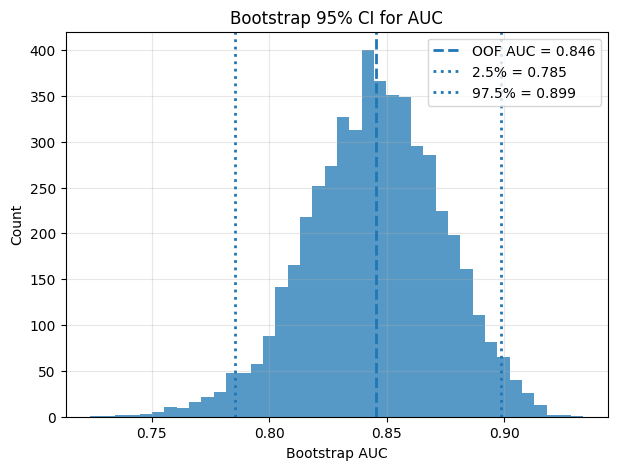


===== Threshold operating table =====


,threshold,accuracy,balanced_accuracy,sensitivity,specificity,PPV,NPV,TP,TN,FP,FN
0,0.30,0.771028,0.708251,0.948148,0.468354,0.752941,0.840909,128,37,42,7
1,0.35,0.780374,0.723535,0.940741,0.506329,0.765060,0.833333,127,40,39,8
2,0.40,0.808411,0.769386,0.918519,0.620253,0.805195,0.816667,124,49,30,11
3,0.45,0.803738,0.770933,0.896296,0.645570,0.812081,0.784615,121,51,28,14
4,0.50,0.808411,0.782513,0.881481,0.683544,0.826389,0.771429,119,54,25,16
5,0.55,0.789720,0.772949,0.837037,0.708861,0.830882,0.717949,113,56,23,22
6,0.60,0.771028,0.766010,0.785185,0.746835,0.841270,0.670455,106,59,20,29
7,0.65,0.724299,0.739475,0.681481,0.797468,0.851852,0.594340,92,63,16,43
8,0.70,0.724299,0.744726,0.666667,0.822785,0.865385,0.590909,90,65,14,45


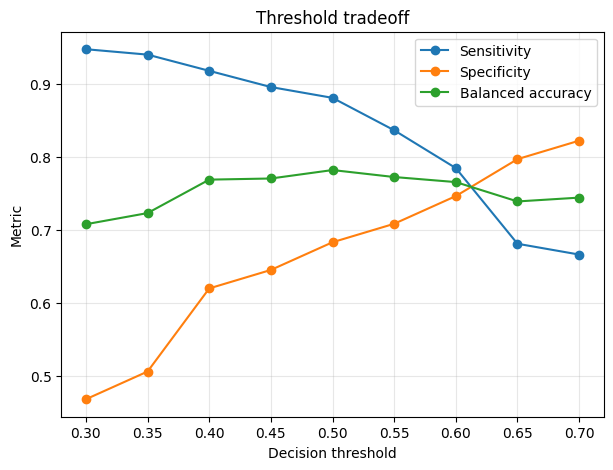

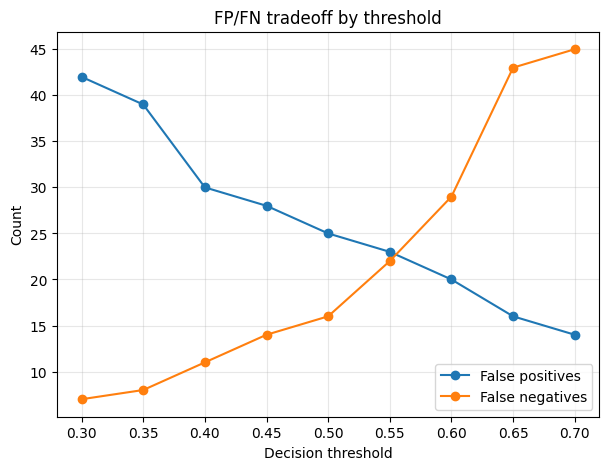


===== Calibration =====
Brier score: 0.150
Mean absolute calibration error: 0.066


,mean_predicted_probability,observed_fraction_ME_CFS,absolute_error
0,0.029844,0.045455,0.015611
1,0.188908,0.238095,0.049187
2,0.373513,0.380952,0.007439
3,0.522826,0.590909,0.068084
4,0.621331,0.809524,0.188193
5,0.751551,0.666667,0.084884
6,0.836610,0.909091,0.072481
7,0.905103,0.761905,0.143198
8,0.953509,0.952381,0.001128
9,0.987037,0.954545,0.032492


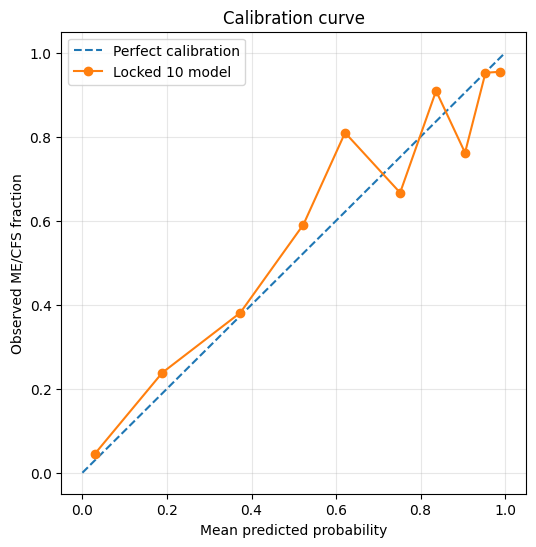


Saved:
..\..\output\locked_panel_biology/locked10_threshold_table.csv
..\..\output\locked_panel_biology/locked10_calibration_table.csv
..\..\output\locked_panel_biology/locked10_oof_probabilities.csv


In [51]:
# =========================
# 2-4. Bootstrap AUC CI + threshold table + calibration
# Locked 10 metabolite panel
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve

# -------------------------
# Data/model
# -------------------------

X_eval = X_panel[LOCKED_PANEL].copy()
y_eval = y.copy()

pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -------------------------
# Out-of-fold probabilities
# -------------------------

oof_probs = cross_val_predict(
    pipe,
    X_eval,
    y_eval,
    cv=cv,
    method="predict_proba"
)[:, 1]

oof_auc = roc_auc_score(y_eval, oof_probs)
oof_brier = brier_score_loss(y_eval, oof_probs)

print("===== OOF performance =====")
print(f"OOF AUC   : {oof_auc:.3f}")
print(f"Brier     : {oof_brier:.3f}")

# -------------------------
# 2. Bootstrap CI for OOF AUC
# -------------------------

N_BOOT = 5000
rng = np.random.default_rng(42)

boot_aucs = []

y_arr = np.asarray(y_eval)
p_arr = np.asarray(oof_probs)

for i in range(N_BOOT):
    idx = rng.choice(len(y_arr), size=len(y_arr), replace=True)

    # skip bootstrap samples with one class only
    if len(np.unique(y_arr[idx])) < 2:
        continue

    boot_aucs.append(
        roc_auc_score(y_arr[idx], p_arr[idx])
    )

boot_aucs = np.array(boot_aucs)

auc_low = np.quantile(boot_aucs, 0.025)
auc_high = np.quantile(boot_aucs, 0.975)

print("\n===== Bootstrap AUC CI =====")
print(f"AUC: {oof_auc:.3f}")
print(f"95% CI: [{auc_low:.3f}, {auc_high:.3f}]")

plt.figure(figsize=(7, 5))
plt.hist(boot_aucs, bins=40, alpha=0.75)
plt.axvline(oof_auc, linestyle="--", linewidth=2, label=f"OOF AUC = {oof_auc:.3f}")
plt.axvline(auc_low, linestyle=":", linewidth=2, label=f"2.5% = {auc_low:.3f}")
plt.axvline(auc_high, linestyle=":", linewidth=2, label=f"97.5% = {auc_high:.3f}")
plt.xlabel("Bootstrap AUC")
plt.ylabel("Count")
plt.title("Bootstrap 95% CI for AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 3. Threshold table
# -------------------------

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

threshold_rows = []

for t in thresholds:
    preds = (oof_probs >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, preds).ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

    threshold_rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_eval, preds),
        "balanced_accuracy": balanced_accuracy_score(y_eval, preds),
        "sensitivity": sens,
        "specificity": spec,
        "PPV": ppv,
        "NPV": npv,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })

threshold_df = pd.DataFrame(threshold_rows)

print("\n===== Threshold operating table =====")
display(threshold_df)

plt.figure(figsize=(7, 5))
plt.plot(threshold_df["threshold"], threshold_df["sensitivity"], marker="o", label="Sensitivity")
plt.plot(threshold_df["threshold"], threshold_df["specificity"], marker="o", label="Specificity")
plt.plot(threshold_df["threshold"], threshold_df["balanced_accuracy"], marker="o", label="Balanced accuracy")
plt.xlabel("Decision threshold")
plt.ylabel("Metric")
plt.title("Threshold tradeoff")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(threshold_df["threshold"], threshold_df["FP"], marker="o", label="False positives")
plt.plot(threshold_df["threshold"], threshold_df["FN"], marker="o", label="False negatives")
plt.xlabel("Decision threshold")
plt.ylabel("Count")
plt.title("FP/FN tradeoff by threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# 4. Calibration table + plot
# -------------------------

prob_true, prob_pred = calibration_curve(
    y_eval,
    oof_probs,
    n_bins=10,
    strategy="quantile"
)

calibration_df = pd.DataFrame({
    "mean_predicted_probability": prob_pred,
    "observed_fraction_ME_CFS": prob_true,
})

calibration_df["absolute_error"] = (
    calibration_df["mean_predicted_probability"] -
    calibration_df["observed_fraction_ME_CFS"]
).abs()

mean_abs_cal_error = calibration_df["absolute_error"].mean()

print("\n===== Calibration =====")
print(f"Brier score: {oof_brier:.3f}")
print(f"Mean absolute calibration error: {mean_abs_cal_error:.3f}")
display(calibration_df)

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(prob_pred, prob_true, marker="o", label="Locked 10 model")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed ME/CFS fraction")
plt.title("Calibration curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# -------------------------
# Save outputs
# -------------------------

threshold_df.to_csv(f"{OUT_DIR}/locked10_threshold_table.csv", index=False)
calibration_df.to_csv(f"{OUT_DIR}/locked10_calibration_table.csv", index=False)

pd.DataFrame({
    "patient_id": X_eval.index.astype(str),
    "y_true": y_eval.values,
    "oof_prob": oof_probs
}).to_csv(f"{OUT_DIR}/locked10_oof_probabilities.csv", index=False)

print("\nSaved:")
print(f"{OUT_DIR}/locked10_threshold_table.csv")
print(f"{OUT_DIR}/locked10_calibration_table.csv")
print(f"{OUT_DIR}/locked10_oof_probabilities.csv")